In [1]:
import pandas as pd
import numpy as np

df_complete = pd.read_csv("aidata_clean.csv")
df_complete.head()

,YEAR,CURRENT ROUND,TEAM NO 1,TEAM 1,SEED 1,TEAM NO 2,TEAM 2,SEED 2,TEAM 1 WIN,SEED DIFF,...,ap_AP RANK_DIFF,ap_AP_RANKED_DIFF,loc_DISTANCE1,loc_DISTANCE2,loc_TZ1,loc_TZ2,loc_DISTANCE_DIFF,loc_DISTANCE_ABS,loc_TZ_DIFF,loc_TZ_ABS
0,2008,64,34,Mississippi St.,8,27,Oregon,9,1,-1,...,4.0,0.0,216.967999,1753.585322,0.0,2.0,-1536.617323,1536.617323,-2.0,2.0
1,2008,64,1,Xavier,3,46,Georgia,14,1,-11,...,-26.0,1.0,401.468192,490.346937,0.0,0.0,-88.878744,88.878744,0.0,0.0
2,2008,64,24,Purdue,6,61,Baylor,11,1,-5,...,-13.0,1.0,535.087958,1240.076851,0.0,1.0,-704.988893,704.988893,-1.0,1.0
3,2008,64,54,Connecticut,4,21,San Diego,13,0,-9,...,NaN,NaN,1116.789827,2086.194014,0.0,3.0,-969.404187,969.404187,-3.0,3.0
4,2008,64,50,Drake,5,4,Western Kentucky,12,0,-7,...,-20.0,1.0,1133.311699,665.578537,1.0,1.0,467.733162,467.733162,0.0,0.0


In [2]:
df_complete = df_complete[df_complete['CURRENT ROUND'] > 4]
df_complete.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1019 entries, 0 to 1068
Columns: 295 entries, YEAR to loc_TZ_ABS
dtypes: float64(255), int64(38), object(2)
memory usage: 2.3+ MB


### Get all the imports ready first

In [3]:
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score
from sklearn.linear_model import LogisticRegression
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.linear_model import LassoCV
import lightgbm as lgb
from sklearn.model_selection import GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler




In [4]:
actual_cols = ['YEAR', 'TEAM NO 1', 'TEAM 1', 'SEED 1', 'TEAM NO 2', 'TEAM 2', 'SEED 2', 'CURRENT ROUND', 'kp_pre_PRESEASON KADJ EM_DIFF', 'rppf_RADJ EM_DIFF', 'kp_pre_KADJ EM CHANGE_DIFF', 'rppf_pre_RPPF RATING CHANGE RANK_DIFF', 
               'kp_pre_PRESEASON KADJ O_DIFF', 'z_SEED LIST_DIFF', 'bart_TALENT_DIFF', 'ap_AP VOTES_DIFF','bart_BADJ O_DIFF', 'rppf_RADJ O_DIFF', 'shoot_FARTHER TWOS FG%_DIFF',
               'teamrank_CONSISTENCY TR RATING_DIFF', 'SEED DIFF', 'bart_WAB_DIFF', 'TEAM 1 WIN']
df_complete2 = df_complete[actual_cols]
df_complete2.info()


<class 'pandas.core.frame.DataFrame'>
Index: 1019 entries, 0 to 1068
Data columns (total 23 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   YEAR                                   1019 non-null   int64  
 1   TEAM NO 1                              1019 non-null   int64  
 2   TEAM 1                                 1019 non-null   object 
 3   SEED 1                                 1019 non-null   int64  
 4   TEAM NO 2                              1019 non-null   int64  
 5   TEAM 2                                 1019 non-null   object 
 6   SEED 2                                 1019 non-null   int64  
 7   CURRENT ROUND                          1019 non-null   int64  
 8   kp_pre_PRESEASON KADJ EM_DIFF          779 non-null    float64
 9   rppf_RADJ EM_DIFF                      779 non-null    float64
 10  kp_pre_KADJ EM CHANGE_DIFF             777 non-null    float64
 11  rppf_pre_

In [5]:
df_complete2 = df_complete2[df_complete2['YEAR'] > 2011]
df_complete2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 779 entries, 252 to 1068
Data columns (total 23 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   YEAR                                   779 non-null    int64  
 1   TEAM NO 1                              779 non-null    int64  
 2   TEAM 1                                 779 non-null    object 
 3   SEED 1                                 779 non-null    int64  
 4   TEAM NO 2                              779 non-null    int64  
 5   TEAM 2                                 779 non-null    object 
 6   SEED 2                                 779 non-null    int64  
 7   CURRENT ROUND                          779 non-null    int64  
 8   kp_pre_PRESEASON KADJ EM_DIFF          779 non-null    float64
 9   rppf_RADJ EM_DIFF                      779 non-null    float64
 10  kp_pre_KADJ EM CHANGE_DIFF             777 non-null    float64
 11  rppf_pre

In [6]:
df_complete2.drop(columns = ['rppf_pre_RPPF RATING CHANGE RANK_DIFF', 'z_SEED LIST_DIFF', 'ap_AP VOTES_DIFF'], inplace = True)
df_complete2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 779 entries, 252 to 1068
Data columns (total 20 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   YEAR                                 779 non-null    int64  
 1   TEAM NO 1                            779 non-null    int64  
 2   TEAM 1                               779 non-null    object 
 3   SEED 1                               779 non-null    int64  
 4   TEAM NO 2                            779 non-null    int64  
 5   TEAM 2                               779 non-null    object 
 6   SEED 2                               779 non-null    int64  
 7   CURRENT ROUND                        779 non-null    int64  
 8   kp_pre_PRESEASON KADJ EM_DIFF        779 non-null    float64
 9   rppf_RADJ EM_DIFF                    779 non-null    float64
 10  kp_pre_KADJ EM CHANGE_DIFF           777 non-null    float64
 11  kp_pre_PRESEASON KADJ O_DIFF      

In [152]:
df_for_modeling = df_complete2.drop(columns = ['TEAM NO 1', 'TEAM 1', 'TEAM NO 2', 'TEAM 2'])
df_for_training = df_for_modeling[df_for_modeling['YEAR'] < 2023]
df_for_testing = df_for_modeling[df_for_modeling['YEAR'] >= 2023]
X_train = df_for_training.drop(columns = ['YEAR', 'TEAM 1 WIN'])
y_train = df_for_training['TEAM 1 WIN']
X_test = df_for_testing.drop(columns = ['YEAR', 'TEAM 1 WIN'])
y_test = df_for_testing['TEAM 1 WIN']
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((599, 14), (599,), (180, 14), (180,))

### Naive Model, #1

In [153]:
y_test_pred_naive = np.ones(len(y_test))
print(classification_report(y_test, y_test_pred_naive, digits=4))

              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000        62
           1     0.6556    1.0000    0.7919       118

    accuracy                         0.6556       180
   macro avg     0.3278    0.5000    0.3960       180
weighted avg     0.4298    0.6556    0.5192       180



C:\Users\BQFAN\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\BQFAN\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\BQFAN\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_clas

In [154]:
X_dummy = X_test.copy()
X_dummy['SEED DIFF BINARY'] = X_dummy['SEED DIFF'].apply(lambda x: 1 if x < 0 else 0)
results_counts = pd.Series(list(zip(y_test, X_dummy['SEED DIFF BINARY']))).value_counts().to_dict()
print(results_counts)

{(1, 1): 101, (0, 1): 32, (0, 0): 30, (1, 0): 17}


In [155]:
y_test_pred_naive2 = X_test['SEED DIFF'].apply(lambda x: 1 if x < 0 else 0)
print(classification_report(y_test, y_test_pred_naive2, digits=4))

              precision    recall  f1-score   support

           0     0.6383    0.4839    0.5505        62
           1     0.7594    0.8559    0.8048       118

    accuracy                         0.7278       180
   macro avg     0.6988    0.6699    0.6776       180
weighted avg     0.7177    0.7278    0.7172       180



In [156]:
numeric = [col for col in X_train.columns if col != "CURRENT ROUND"]
categorical = ["CURRENT ROUND"] if "CURRENT ROUND" in X_train.columns else []
preprocessor = ColumnTransformer(
    [
        ("num", Pipeline([("imp", SimpleImputer(strategy="median")), ("sc", StandardScaler())]), numeric),
        (
            "cat",
            Pipeline(
                [
                    ("imp", SimpleImputer(strategy="most_frequent")),
                    ("oh", OneHotEncoder(handle_unknown="ignore")),
                ]
            ),
            categorical,
        ),
    ],
    remainder="drop",
)
pipeline = Pipeline([("preprocessor", preprocessor), ("model", LogisticRegression(random_state=8, solver = 'liblinear', max_iter=6000, C=10))])
pipeline.fit(X_train, y_train)
y_test_pred = pipeline.predict(X_test)
print(classification_report(y_test, y_test_pred, digits=4))

              precision    recall  f1-score   support

           0     0.7241    0.6774    0.7000        62
           1     0.8361    0.8644    0.8500       118

    accuracy                         0.8000       180
   macro avg     0.7801    0.7709    0.7750       180
weighted avg     0.7975    0.8000    0.7983       180



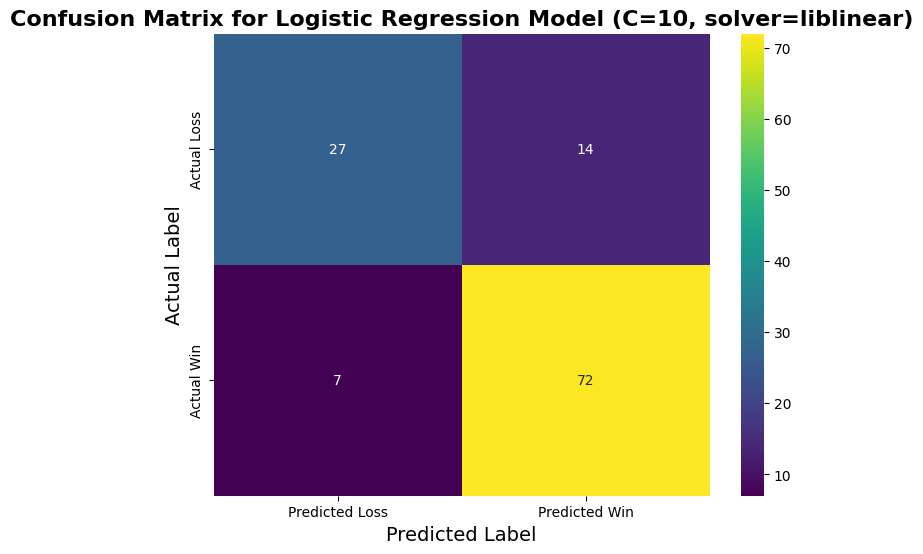

In [121]:
cm_logistic = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_logistic, annot=True, fmt='d', cmap='viridis', cbar=True, 
            xticklabels=['Predicted Loss', 'Predicted Win'], 
            yticklabels=['Actual Loss', 'Actual Win'])
plt.xlabel('Predicted Label', fontsize=14)
plt.ylabel('Actual Label', fontsize=14)
plt.title('Confusion Matrix for Logistic Regression Model (C=10, solver=liblinear)', fontsize=16, fontweight='bold')
plt.show()

In [157]:
###Naive Logistic Regression
X_train_naive = X_train[['SEED DIFF', 'CURRENT ROUND', 'kp_pre_PRESEASON KADJ EM_DIFF']]
X_test_naive = X_test[['SEED DIFF', 'CURRENT ROUND', 'kp_pre_PRESEASON KADJ EM_DIFF']]
sc_naive = StandardScaler()
X_train_naive_scaled = sc_naive.fit_transform(X_train_naive)
X_test_naive_scaled = sc_naive.transform(X_test_naive)
logistic_naive = LogisticRegression(random_state=8, solver='liblinear', max_iter=6000, C=10)
logistic_naive.fit(X_train_naive_scaled, y_train)
y_test_pred_naive = logistic_naive.predict(X_test_naive_scaled)
print(classification_report(y_test, y_test_pred_naive, digits=4))

              precision    recall  f1-score   support

           0     0.6727    0.5968    0.6325        62
           1     0.8000    0.8475    0.8230       118

    accuracy                         0.7611       180
   macro avg     0.7364    0.7221    0.7278       180
weighted avg     0.7562    0.7611    0.7574       180



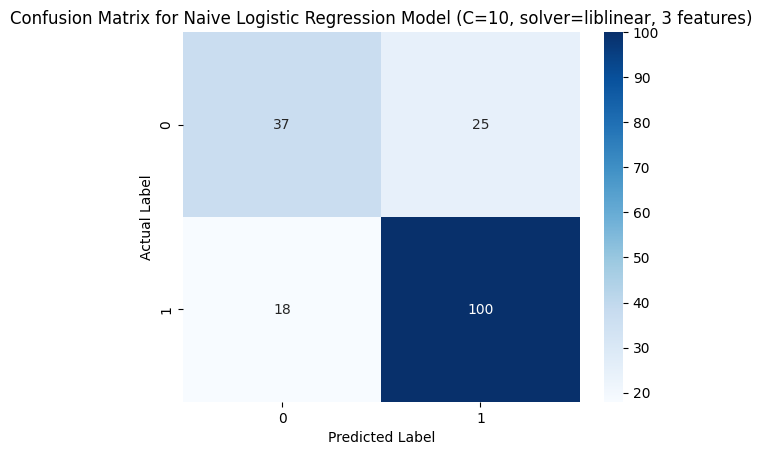

In [158]:
cm_naive_logistic = confusion_matrix(y_test, y_test_pred_naive)
sns.heatmap(cm_naive_logistic, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix for Naive Logistic Regression Model (C=10, solver=liblinear, 3 features)')
plt.show()

In [162]:
results = []
for actual, baseline, prediction in zip(y_test, X_dummy['SEED DIFF BINARY'], y_test_pred_naive):
    if prediction == actual:
        # If the model is correct, determine if it was an Upset or Non-Upset
        if baseline != actual:
            results.append("Correct Upset Prediction")
        else:
            results.append("Correct Non-Upset Prediction")
    else:
        # If the model results = []is wrong, it's a misprediction
        if baseline != actual:
            results.append("Mispredicted Upset")
        else:
            results.append("Mispredicted Non-Upset")

# 2. Convert to a dictionary of counts
three_way_stats = pd.Series(results).value_counts().to_dict()

# 3. Print the results
print("Four-Way Detection Results:")
for category, count in three_way_stats.items():
    print(f"  {category}: {count}")

Four-Way Detection Results:
  Correct Non-Upset Prediction: 127
  Mispredicted Upset: 39
  Correct Upset Prediction: 10
  Mispredicted Non-Upset: 4


In [126]:
X_dummy2 = df_for_modeling.copy()
X_dummy2['SEED DIFF']


252     -5
253    -15
254     -1
255     -7
256     -9
        ..
1064     8
1065     3
1066     1
1067    -8
1068     3
Name: SEED DIFF, Length: 779, dtype: int64

In [128]:
win_analysis = pd.DataFrame({
    'SEED DIFF': X_dummy2['SEED DIFF'],
    'TEAM 1 WIN': X_dummy2['TEAM 1 WIN']
})

# Group by SEED DIFF and count Team 1 wins vs. losses
# A negative SEED DIFF means Team 1 is the better (lower) seed
seed_win_counts = win_analysis.groupby('SEED DIFF')['TEAM 1 WIN'].value_counts().unstack(fill_value=0)
seed_win_counts.columns = ['Team 1 Loss', 'Team 1 Win']

# Calculate Win Percentage for Team 1 at each Seed Diff
seed_win_counts['Win %'] = (seed_win_counts['Team 1 Win'] / 
                           (seed_win_counts['Team 1 Win'] + seed_win_counts['Team 1 Loss']) * 100)

print("Team 1 Win Rate by Seed Differential:")
print(seed_win_counts.sort_index())

Team 1 Win Rate by Seed Differential:
           Team 1 Loss  Team 1 Win      Win %
SEED DIFF                                    
-15                  2          50  96.153846
-13                  7          45  86.538462
-12                  1           3  75.000000
-11                  7          47  87.037037
-10                  1           2  66.666667
-9                  11          44  80.000000
-8                   6          33  84.615385
-7                  28          54  65.853659
-5                  26          30  53.571429
-4                   9          16  64.000000
-3                  29          54  65.060241
-2                   3           8  72.727273
-1                  34          39  53.424658
 1                  27          19  41.304348
 2                   1           0   0.000000
 3                  17           9  34.615385
 4                   9           5  35.714286
 5                  18          12  40.000000
 6                   1           2  66.666

In [125]:
win_analysis = pd.DataFrame({
    'SEED DIFF': X_dummy['SEED DIFF'],
    'TEAM 1 WIN': y_test
})

# Group by SEED DIFF and count Team 1 wins vs. losses
# A negative SEED DIFF means Team 1 is the better (lower) seed
seed_win_counts = win_analysis.groupby('SEED DIFF')['TEAM 1 WIN'].value_counts().unstack(fill_value=0)
seed_win_counts.columns = ['Team 1 Loss', 'Team 1 Win']

# Calculate Win Percentage for Team 1 at each Seed Diff
seed_win_counts['Win %'] = (seed_win_counts['Team 1 Win'] / 
                           (seed_win_counts['Team 1 Win'] + seed_win_counts['Team 1 Loss']) * 100)

print("Team 1 Win Rate by Seed Differential:")
print(seed_win_counts.sort_index())

Team 1 Win Rate by Seed Differential:
           Team 1 Loss  Team 1 Win       Win %
SEED DIFF                                     
-15                  0           8  100.000000
-13                  0           8  100.000000
-11                  1           7   87.500000
-9                   1           7   87.500000
-8                   0           6  100.000000
-7                   5           8   61.538462
-5                   4           4   50.000000
-4                   0           3  100.000000
-3                   5           9   64.285714
-2                   0           3  100.000000
-1                   5           7   58.333333
 1                   3           3   50.000000
 3                   1           3   75.000000
 4                   2           1   33.333333
 5                   5           0    0.000000
 8                   9           1   10.000000
 9                   0           1  100.000000


In [17]:
# Create a dataframe for the three-way comparison
upset_analysis = pd.DataFrame({
    'SEED DIFF': X_dummy['SEED DIFF'],
    'Actual': y_test,
    'Model_Pred': y_test_pred
})

# Define an "Actual Upset":
# 1. Team 1 is better seed (DIFF < 0) but Team 2 wins (Actual == 0)
# 2. Team 2 is better seed (DIFF > 0) but Team 1 wins (Actual == 1)
upset_filter = (
    ((upset_analysis['SEED DIFF'] < 0) & (upset_analysis['Actual'] == 0)) |
    ((upset_analysis['SEED DIFF'] > 0) & (upset_analysis['Actual'] == 1))
)

actual_upsets = upset_analysis[upset_filter].copy()

# Determine if the model correctly predicted these specific upsets
actual_upsets['Model_Correct'] = (actual_upsets['Actual'] == actual_upsets['Model_Pred'])

# Group by the magnitude of the seed difference to see which upsets are "easier" to catch
# We use the absolute value of SEED DIFF to group by the 'size' of the upset (e.g., a 5-vs-12)
actual_upsets['Abs_Seed_Diff'] = actual_upsets['SEED DIFF'].abs()

upset_stats = actual_upsets.groupby('Abs_Seed_Diff')['Model_Correct'].value_counts().unstack(fill_value=0)
upset_stats.columns = ['Failed to Predict Upset', 'Correctly Predicted Upset']

print("\nModel Performance on Actual Upsets (Categorized by Seed Gap):")
print(upset_stats.sort_index())


Model Performance on Actual Upsets (Categorized by Seed Gap):
               Failed to Predict Upset  Correctly Predicted Upset
Abs_Seed_Diff                                                    
1                                    3                         10
3                                    4                          7
4                                    1                          2
5                                    3                          4
6                                    0                          1
7                                    5                          1
8                                    1                          1
9                                    2                          1
11                                   1                          0
13                                   1                          0
15                                   1                          0


### SVC

In [160]:
svc_model = SVC(random_state=8, C=5, kernel='linear')
pipeline = Pipeline([("preprocessor", preprocessor), ("model", svc_model)])
pipeline.fit(X_train, y_train)
y_test_pred_svc = pipeline.predict(X_test)
print(classification_report(y_test, y_test_pred_svc, digits=4))

              precision    recall  f1-score   support

           0     0.7593    0.6613    0.7069        62
           1     0.8333    0.8898    0.8607       118

    accuracy                         0.8111       180
   macro avg     0.7963    0.7756    0.7838       180
weighted avg     0.8078    0.8111    0.8077       180



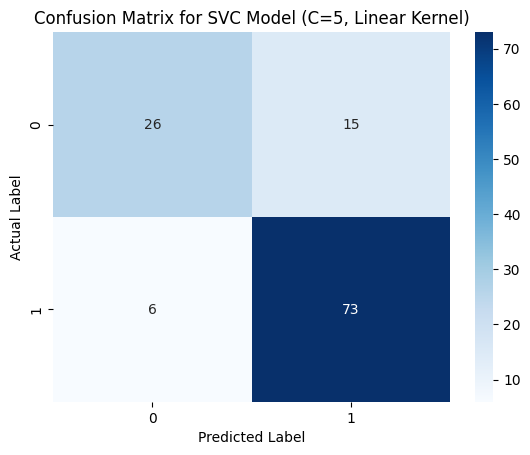

In [130]:
confusion_svc = confusion_matrix(y_test, y_test_pred_svc)
sns.heatmap(confusion_svc, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix for SVC Model (C=5, Linear Kernel)')
plt.show()

In [161]:
results = []
for actual, baseline, prediction in zip(y_test, X_dummy['SEED DIFF BINARY'], y_test_pred_svc):
    if prediction == actual:
        # If the model is correct, determine if it was an Upset or Non-Upset
        if baseline != actual:
            results.append("Correct Upset Prediction")
        else:
            results.append("Correct Non-Upset Prediction")
    else:
        # If the model results = []is wrong, it's a misprediction
        if baseline != actual:
            results.append("Mispredicted Upset")
        else:
            results.append("Mispredicted Non-Upset")

# 2. Convert to a dictionary of counts
three_way_stats = pd.Series(results).value_counts().to_dict()

# 3. Print the results
print("Four-Way Detection Results:")
for category, count in three_way_stats.items():
    print(f"  {category}: {count}")

Four-Way Detection Results:
  Correct Non-Upset Prediction: 118
  Correct Upset Prediction: 28
  Mispredicted Upset: 21
  Mispredicted Non-Upset: 13


### KNN ? 

In [163]:
knn_model = KNeighborsClassifier(n_neighbors=25)
pipeline = Pipeline([("preprocessor", preprocessor), ("model", knn_model)])
pipeline.fit(X_train, y_train)
y_test_pred_knn = pipeline.predict(X_test)
print(classification_report(y_test, y_test_pred_knn, digits=4))

              precision    recall  f1-score   support

           0     0.6333    0.6129    0.6230        62
           1     0.8000    0.8136    0.8067       118

    accuracy                         0.7444       180
   macro avg     0.7167    0.7132    0.7148       180
weighted avg     0.7426    0.7444    0.7434       180



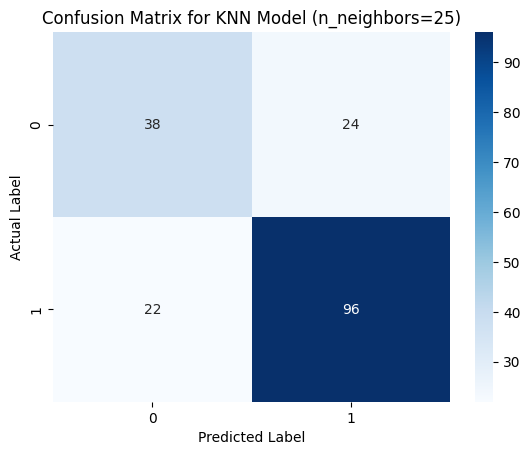

In [164]:
confusion_knn = confusion_matrix(y_test, y_test_pred_knn)
sns.heatmap(confusion_knn, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix for KNN Model (n_neighbors=25)')
plt.show()

In [165]:
results = []
for actual, baseline, prediction in zip(y_test, X_dummy['SEED DIFF BINARY'], y_test_pred_knn):
    if prediction == actual:
        # If the model is correct, determine if it was an Upset or Non-Upset
        if baseline != actual:
            results.append("Correct Upset Prediction")
        else:
            results.append("Correct Non-Upset Prediction")
    else:
        # If the model results = []is wrong, it's a misprediction
        if baseline != actual:
            results.append("Mispredicted Upset")
        else:
            results.append("Mispredicted Non-Upset")

# 2. Convert to a dictionary of counts
three_way_stats = pd.Series(results).value_counts().to_dict()

# 3. Print the results
print("Four-Way Detection Results:")
for category, count in three_way_stats.items():
    print(f"  {category}: {count}")

Four-Way Detection Results:
  Correct Non-Upset Prediction: 123
  Mispredicted Upset: 38
  Correct Upset Prediction: 11
  Mispredicted Non-Upset: 8


### Random Forest Model

In [24]:
n_estimators_list = [100, 250, 500, 1000, 2500]
max_depth_list = [5, 8, 10, 12, 15]
for n in n_estimators_list:
    for d in max_depth_list:
        random_forest_model = RandomForestClassifier(random_state=8, n_estimators=n, max_depth=d)
        pipeline = Pipeline([("preprocessor", preprocessor), ("model", random_forest_model)])
        pipeline.fit(X_train, y_train)
        y_test_pred_rf = pipeline.predict(X_test)
        print(f"n_estimators: {n}, max_depth: {d}")
        print(classification_report(y_test, y_test_pred_rf, digits=4))

n_estimators: 100, max_depth: 5
              precision    recall  f1-score   support

           0     0.6182    0.5484    0.5812        62
           1     0.7760    0.8220    0.7984       118

    accuracy                         0.7278       180
   macro avg     0.6971    0.6852    0.6898       180
weighted avg     0.7216    0.7278    0.7236       180

n_estimators: 100, max_depth: 8
              precision    recall  f1-score   support

           0     0.5968    0.5968    0.5968        62
           1     0.7881    0.7881    0.7881       118

    accuracy                         0.7222       180
   macro avg     0.6925    0.6925    0.6925       180
weighted avg     0.7222    0.7222    0.7222       180

n_estimators: 100, max_depth: 10
              precision    recall  f1-score   support

           0     0.6034    0.5645    0.5833        62
           1     0.7787    0.8051    0.7917       118

    accuracy                         0.7222       180
   macro avg     0.6911    0.68

In [166]:
random_forest_model = RandomForestClassifier(random_state=8, n_estimators=1000, max_depth=15)
pipeline = Pipeline([("preprocessor", preprocessor), ("model", random_forest_model)])
pipeline.fit(X_train, y_train)
y_test_pred_rf = pipeline.predict(X_test)
print(classification_report(y_test, y_test_pred_rf, digits=4))

              precision    recall  f1-score   support

           0     0.6333    0.6129    0.6230        62
           1     0.8000    0.8136    0.8067       118

    accuracy                         0.7444       180
   macro avg     0.7167    0.7132    0.7148       180
weighted avg     0.7426    0.7444    0.7434       180



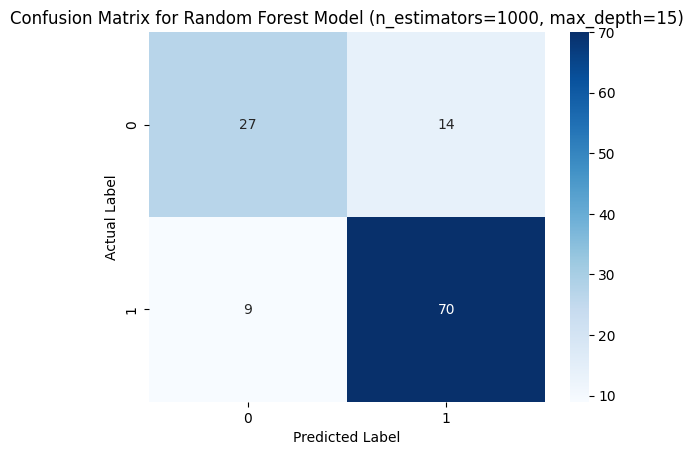

In [137]:
cm_rf = confusion_matrix(y_test, y_test_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix for Random Forest Model (n_estimators=1000, max_depth=15)')
plt.show()

In [27]:
import shap
shap.initjs()


### XGBoost and LightGBM

In [167]:
d_train = xgb.DMatrix(X_train, label=y_train)
d_test = xgb.DMatrix(X_test, label=y_test)

params = {
    "eta": 0.003,
    "objective": "binary:logistic",
    "subsample": 0.5,
    "base_score": np.mean(y_train),
    "eval_metric": "logloss",
}
xgb_model = xgb.train(
    params,
    d_train,
    3000,
    evals=[(d_test, "test")],
    verbose_eval=100,
    early_stopping_rounds=200,
)

[0]	test-logloss:0.64585


[100]	test-logloss:0.59841
[200]	test-logloss:0.57001
[300]	test-logloss:0.55155
[400]	test-logloss:0.54080
[500]	test-logloss:0.53267
[600]	test-logloss:0.52882
[700]	test-logloss:0.52558
[800]	test-logloss:0.52516
[900]	test-logloss:0.52418
[1000]	test-logloss:0.52500
[1100]	test-logloss:0.52630
[1164]	test-logloss:0.52666


In [168]:
y_pred_xgb = xgb_model.predict(d_test)
y_pred_xgb_binary = [1 if pred >= 0.5 else 0 for pred in y_pred_xgb]
print(classification_report(y_test, y_pred_xgb_binary, digits=4))

              precision    recall  f1-score   support

           0     0.6207    0.5806    0.6000        62
           1     0.7869    0.8136    0.8000       118

    accuracy                         0.7333       180
   macro avg     0.7038    0.6971    0.7000       180
weighted avg     0.7296    0.7333    0.7311       180



In [169]:
d_train = lgb.Dataset(X_train, label=y_train)
d_test = lgb.Dataset(X_test, label=y_test)
d_test

In [170]:
params = {
    "max_bin": 512, 
    "learning_rate": 0.001,
    "objective": "binary",
    "metric": "binary_logloss",
    "num_leaves": 15, 
    "verbose": 100, 
    "min_data": 100,
    "boost_from_average": True, 
    "early_stopping_round": 50,
}

lgb_model = lgb.train(
    params,
    d_train,
    5000,
    valid_sets = [d_test],
)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 372, number of negative: 227
[LightGBM] [Debug] Dataset::GetMultiBinFromAllFeatures: sparse rate 0.004770
[LightGBM] [Debug] init for col-wise cost 0.000004 seconds, init for row-wise cost 0.000172 seconds
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000437 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1682
[LightGBM] [Info] Number of data points in the train set: 599, number of used features: 14
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.621035 -> initscore=0.493944
[LightGBM] [Info] Start training from score 0.493944
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Debug] Trained a tree with leaves = 5 and depth = 3
Training until validation scores don't

In [145]:
explainer = shap.TreeExplainer(lgb_model)
shap_values = explainer(X_test)

In [172]:
y_pred_lgb = lgb_model.predict(X_test)
y_pred_lgb_binary = [1 if pred >= 0.35 else 0 for pred in y_pred_lgb]
print(classification_report(y_test, y_pred_lgb_binary, digits=4))

              precision    recall  f1-score   support

           0     0.8125    0.4194    0.5532        62
           1     0.7568    0.9492    0.8421       118

    accuracy                         0.7667       180
   macro avg     0.7846    0.6843    0.6976       180
weighted avg     0.7760    0.7667    0.7426       180



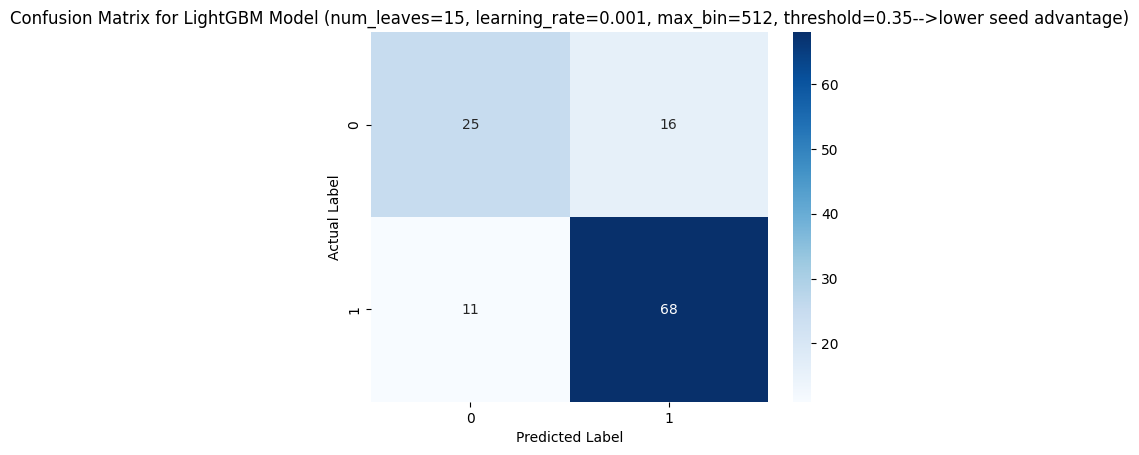

In [148]:
cm_lgb = confusion_matrix(y_test, y_pred_lgb_binary)
sns.heatmap(cm_lgb, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix for LightGBM Model (num_leaves=15, learning_rate=0.001, max_bin=512, threshold=0.35-->lower seed advantage)')
plt.show()

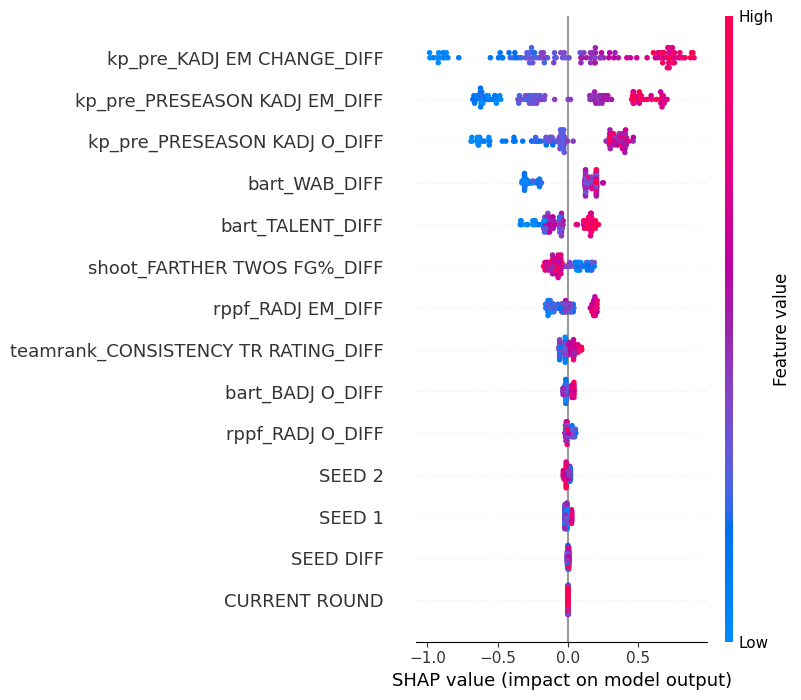

In [149]:
shap.summary_plot(shap_values, X_test)

### LASSO 

In [173]:
lasso_model = LogisticRegression(max_iter=1000, random_state=8, penalty='l1', solver='liblinear', C=10)
pipeline = Pipeline([("preprocessor", preprocessor), ("model", lasso_model)])
pipeline.fit(X_train, y_train)
y_test_pred_lasso = pipeline.predict(X_test)
print(classification_report(y_test, y_test_pred_lasso, digits=4))

              precision    recall  f1-score   support

           0     0.7368    0.6774    0.7059        62
           1     0.8374    0.8729    0.8548       118

    accuracy                         0.8056       180
   macro avg     0.7871    0.7752    0.7803       180
weighted avg     0.8028    0.8056    0.8035       180



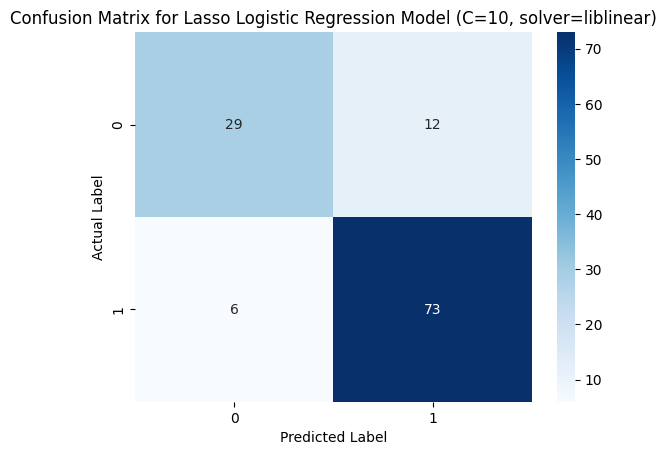

In [151]:
cm_lasso = confusion_matrix(y_test, y_test_pred_lasso)
sns.heatmap(cm_lasso, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix for Lasso Logistic Regression Model (C=10, solver=liblinear)')
plt.show()

### Now we officially enter the "leave one out" era for the models that we had fitted and optimized

In [45]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

val_years = sorted(df_for_modeling['YEAR'].unique())
all_results = []

# Features for models using the full set
X_features = X_train.columns.tolist()
# Features for the Naive Logistic Regression
naive_logreg_features = ['SEED DIFF', 'CURRENT ROUND', 'kp_pre_PRESEASON KADJ EM_DIFF']

for year in val_years:
    # --- A. Split Fold ---
    # Training on all years EXCEPT the current validation year
    train_fold = df_for_modeling[df_for_modeling['YEAR'] != year]
    val_fold = df_for_modeling[df_for_modeling['YEAR'] == year]
    
    X_train_fold = train_fold.drop(columns=['YEAR', 'TEAM 1 WIN'])
    y_train_fold = train_fold['TEAM 1 WIN']
    X_val_fold = val_fold.drop(columns=['YEAR', 'TEAM 1 WIN'])
    y_val_fold = val_fold['TEAM 1 WIN']

    # --- B. Naive Seed Baseline (No Training Needed) ---
    # Prediction: Better seed (lower number) wins
    y_seed_pred = (val_fold['SEED 1'] < val_fold['SEED 2']).astype(int)
    
    # --- C. Naive Logistic Regression (Manual Setup) ---
    sc_naive = StandardScaler()
    X_tr_n = sc_naive.fit_transform(X_train_fold[naive_logreg_features])
    X_val_n = sc_naive.transform(X_val_fold[naive_logreg_features])
    logistic_naive.fit(X_tr_n, y_train_fold)
    y_naive_lr_pred = logistic_naive.predict(X_val_n)

    lr_model = LogisticRegression(random_state=8, solver = 'liblinear', max_iter=6000, C=10)
    lasso_model = LogisticRegression(max_iter=1000, random_state=8, penalty='l1', solver='liblinear', C=10)
    svc_model = SVC(random_state=8, C=5, kernel='linear')
    knn_model = KNeighborsClassifier(n_neighbors=25)
    random_forest_model = RandomForestClassifier(random_state=8, n_estimators=1000, max_depth=15)
    # --- D. Main Models (Using Pipeline) ---
    # We update the pipeline step with each specific model for this fold
    model_preds = {}
    standard_models = {
        'LR': lr_model, 'LASSO': lasso_model, 'SVC': svc_model, 'KNN': knn_model, 
        'RF': random_forest_model
    }

    for name, model_obj in standard_models.items():
        # Update pipeline with the current model and fit
        if name in ['LR', 'LASSO', 'SVC', 'KNN']:
            pipeline.set_params(model=model_obj)
            pipeline.fit(X_train_fold, y_train_fold)
            model_preds[name] = pipeline.predict(X_val_fold)
        else:
            thisModel = model_obj
            model_obj.fit(X_train_fold, y_train_fold)
            model_preds[name] = model_obj.predict(X_val_fold)
        #else:
        #    thisModel = model_obj
        #    model_obj.fit(X_train_fold, y_train_fold)
        #    lgb_probs = model_obj.predict(X_val_fold)
        #    model_preds[name] = (lgb_probs >= 0.5).astype(int)

    # --- E. LGB with Custom 0.35 Threshold ---
    ##pipeline.set_params(model=lgb_model)
    ##pipeline.fit(X_train_fold, y_train_fold)
    ##lgb_probs = pipeline.predict_proba(X_val_fold)[:, 1]
    ##lgb_model.fit(X_train_fold, y_train_fold)
    ##lgb_probs = lgb_model.predict(X_val_fold)
    ##model_preds['LGB_0.35'] = (lgb_probs >= 0.35).astype(int)

    # --- F. Metric Aggregation ---
    def get_metrics(y_true, y_pred):
        return [
            accuracy_score(y_true, y_pred),
            f1_score(y_true, y_pred, average='weighted'),
            precision_score(y_true, y_pred, average='weighted', zero_division=0),
            recall_score(y_true, y_pred, average='weighted')
        ]

    row = [year]
    row.extend(get_metrics(y_val_fold, y_seed_pred)) # Naive Seed
    row.extend(get_metrics(y_val_fold, y_naive_lr_pred)) # Naive LogReg
    for name in ['LR', 'LASSO', 'SVC', 'KNN', 'RF']:
        row.extend(get_metrics(y_val_fold, model_preds[name]))
    
    all_results.append(row)

# 3. Construct Big Dataframe
metric_names = ['Acc', 'F1', 'Prec', 'Rec']
model_names = ['Naive_Seed', 'Naive_LogReg', 'LR', 'LASSO', 'SVC', 'KNN', 'RF']
cols = ['Year'] + [f"{m}_{met}" for m in model_names for met in metric_names]

performance_df = pd.DataFrame(all_results, columns=cols).set_index('Year')
display(performance_df)

,Naive_Seed_Acc,Naive_Seed_F1,Naive_Seed_Prec,Naive_Seed_Rec,Naive_LogReg_Acc,Naive_LogReg_F1,Naive_LogReg_Prec,Naive_LogReg_Rec,LR_Acc,LR_F1,...,SVC_Prec,SVC_Rec,KNN_Acc,KNN_F1,KNN_Prec,KNN_Rec,RF_Acc,RF_F1,RF_Prec,RF_Rec
Year,,,,,,,,,,,,,,,,,,,,,
2012,0.716667,0.685714,0.743599,0.716667,0.700000,0.678819,0.703106,0.700000,0.850000,0.851151,...,0.856566,0.850000,0.683333,0.664387,0.680000,0.683333,0.733333,0.724542,0.731746,0.733333
2013,0.666667,0.645833,0.666667,0.666667,0.683333,0.652502,0.701389,0.683333,0.850000,0.850384,...,0.851077,0.850000,0.683333,0.671952,0.680556,0.683333,0.683333,0.666615,0.684186,0.683333
2014,0.666667,0.652546,0.652462,0.666667,0.633333,0.629304,0.626667,0.633333,0.850000,0.849230,...,0.849422,0.850000,0.683333,0.681707,0.680464,0.683333,0.666667,0.663004,0.660833,0.666667
2015,0.800000,0.791111,0.790835,0.800000,0.750000,0.755617,0.765000,0.750000,0.866667,0.866667,...,0.828889,0.833333,0.733333,0.737566,0.743432,0.733333,0.750000,0.758310,0.776914,0.750000
2016,0.683333,0.652502,0.701389,0.683333,0.733333,0.721612,0.739170,0.733333,0.816667,0.816087,...,0.832942,0.833333,0.700000,0.691388,0.697689,0.700000,0.800000,0.787500,0.829630,0.800000
2017,0.766667,0.755556,0.762222,0.766667,0.733333,0.730000,0.728370,0.733333,0.850000,0.852000,...,0.882500,0.883333,0.716667,0.715005,0.713750,0.716667,0.683333,0.677018,0.674206,0.683333
2018,0.666667,0.661376,0.657547,0.666667,0.683333,0.688906,0.697807,0.683333,0.800000,0.804396,...,0.815981,0.800000,0.683333,0.691463,0.708796,0.683333,0.683333,0.691463,0.708796,0.683333
2019,0.683333,0.665449,0.700000,0.683333,0.716667,0.700664,0.740625,0.716667,0.816667,0.816923,...,0.769410,0.766667,0.716667,0.700664,0.740625,0.716667,0.733333,0.720574,0.754309,0.733333
2021,0.677966,0.647876,0.653120,0.677966,0.677966,0.664663,0.661531,0.677966,0.847458,0.844098,...,0.827936,0.830508,0.711864,0.699962,0.699153,0.711864,0.694915,0.678892,0.678450,0.694915


In [46]:
performance_df.to_csv("Model Performances Train-Validation.csv")

In [47]:
acc_cols = [col for col in performance_df.columns if col.endswith('_Acc')]
acc_df = performance_df[acc_cols]
acc_df.describe()

,Naive_Seed_Acc,Naive_LogReg_Acc,LR_Acc,LASSO_Acc,SVC_Acc,KNN_Acc,RF_Acc
count,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000
mean,0.705997,0.711126,0.830574,0.834420,0.825424,0.711169,0.717558
std,0.053156,0.049055,0.037069,0.037473,0.033020,0.041014,0.058465
min,0.666667,0.633333,0.733333,0.750000,0.766667,0.650000,0.600000
25%,0.666667,0.683333,0.816667,0.800000,0.816667,0.683333,0.683333
50%,0.683333,0.700000,0.850000,0.847458,0.833333,0.711864,0.716667
75%,0.716667,0.733333,0.850000,0.866667,0.850000,0.716667,0.750000
max,0.816667,0.833333,0.866667,0.883333,0.883333,0.816667,0.816667


### Train-Val-Test

In [174]:
# 1. Setup Data Splits
# Validation logic (Historical years)
val_years = sorted(df_for_modeling[df_for_modeling['YEAR'] < 2023]['YEAR'].unique())
# Test logic (The "Blind" years)
test_years = [2023, 2024, 2025]

all_results = []
naive_logreg_features = ['SEED DIFF', 'CURRENT ROUND', 'kp_pre_PRESEASON KADJ EM_DIFF']

# 2. Define Tree-Specific Pipeline (Imputation ONLY, no Scaling)
tree_preprocessor = ColumnTransformer(
    [
        ("num", Pipeline([("imp", SimpleImputer(strategy="median"))]), numeric),
        ("cat", Pipeline([
            ("imp", SimpleImputer(strategy="most_frequent")),
            ("oh", OneHotEncoder(handle_unknown="ignore"))
        ]), categorical),
    ],
    remainder="drop",
)

# Metric Helper Function
def get_metrics(y_true, y_pred):
    return [
        accuracy_score(y_true, y_pred),
        f1_score(y_true, y_pred, average='weighted'),
        precision_score(y_true, y_pred, average='weighted', zero_division=0),
        recall_score(y_true, y_pred, average='weighted')
    ]

# 3. Part 1: Leave-One-Year-Out CV (Years < 2024)
for year in val_years:
    train_fold = df_for_modeling[(df_for_modeling['YEAR'] < 2024) & (df_for_modeling['YEAR'] != year)]
    val_fold = df_for_modeling[df_for_modeling['YEAR'] == year]
    
    X_train_fold = train_fold.drop(columns=['YEAR', 'TEAM 1 WIN'])
    y_train_fold = train_fold['TEAM 1 WIN']
    X_val_fold = val_fold.drop(columns=['YEAR', 'TEAM 1 WIN'])
    y_val_fold = val_fold['TEAM 1 WIN']

    # --- Baseline & Naive LR ---
    y_seed_pred = (val_fold['SEED 1'] < val_fold['SEED 2']).astype(int)
    sc_naive = StandardScaler()
    logistic_naive.fit(sc_naive.fit_transform(X_train_fold[naive_logreg_features]), y_train_fold)
    y_naive_lr_pred = logistic_naive.predict(sc_naive.transform(X_val_fold[naive_logreg_features]))

    # --- Main Models ---
    model_preds = {}
    # Scaled Models
    for name, model_obj in {'LR': lr_model, 'LASSO': lasso_model, 'SVC': svc_model, 'KNN': knn_model}.items():
        pipeline.set_params(model=model_obj)
        pipeline.fit(X_train_fold, y_train_fold)
        model_preds[name] = pipeline.predict(X_val_fold)
    
    # Non-Scaled Tree Model
    rf_pipe = Pipeline([("pre", tree_preprocessor), ("model", random_forest_model)])
    rf_pipe.fit(X_train_fold, y_train_fold)
    model_preds['RF'] = rf_pipe.predict(X_val_fold)

    # --- Collect Results (Initialize as LIST) ---
    row = [year]
    row.extend(get_metrics(y_val_fold, y_seed_pred))
    row.extend(get_metrics(y_val_fold, y_naive_lr_pred))
    for name in ['LR', 'LASSO', 'SVC', 'KNN', 'RF']:
        row.extend(get_metrics(y_val_fold, model_preds[name]))
    all_results.append(row)

# 4. Part 2: Final Test Evaluation (Train < 2024, Test 2024/2025)
df_pre_2024 = df_for_modeling[df_for_modeling['YEAR'] < 2024]
X_train_full = df_pre_2024.drop(columns=['YEAR', 'TEAM 1 WIN'])
y_train_full = df_pre_2024['TEAM 1 WIN']

for year in test_years:
    test_fold = df_for_modeling[df_for_modeling['YEAR'] == year]
    if test_fold.empty: continue
    
    X_test_fold = test_fold.drop(columns=['YEAR', 'TEAM 1 WIN'])
    y_test_fold = test_fold['TEAM 1 WIN']
    
    # Repeat the prediction logic exactly as above, but for the test year...
    # (Abbreviated here to ensure clarity: you repeat the model fits on X_train_full)
    # ...
    # [Insert similar fit/predict logic here for the test_fold]
    # ...
    # all_results.append(test_row)

# 5. Construct Final Big Dataframe
metric_names = ['Acc', 'F1', 'Prec', 'Rec']
model_names = ['Naive_Seed', 'Naive_LogReg', 'LR', 'LASSO', 'SVC', 'KNN', 'RF']
cols = ['Year'] + [f"{m}_{met}" for m in model_names for met in metric_names]
performance_df = pd.DataFrame(all_results, columns=cols).set_index('Year')
display(performance_df)

,Naive_Seed_Acc,Naive_Seed_F1,Naive_Seed_Prec,Naive_Seed_Rec,Naive_LogReg_Acc,Naive_LogReg_F1,Naive_LogReg_Prec,Naive_LogReg_Rec,LR_Acc,LR_F1,...,SVC_Prec,SVC_Rec,KNN_Acc,KNN_F1,KNN_Prec,KNN_Rec,RF_Acc,RF_F1,RF_Prec,RF_Rec
Year,,,,,,,,,,,,,,,,,,,,,
2012,0.716667,0.685714,0.743599,0.716667,0.700000,0.678819,0.703106,0.700000,0.850000,0.851151,...,0.837104,0.833333,0.750000,0.735043,0.760000,0.750000,0.716667,0.705032,0.714911,0.716667
2013,0.666667,0.645833,0.666667,0.666667,0.683333,0.652502,0.701389,0.683333,0.866667,0.866667,...,0.866823,0.866667,0.666667,0.652015,0.663019,0.666667,0.733333,0.721612,0.739170,0.733333
2014,0.666667,0.652546,0.652462,0.666667,0.650000,0.643841,0.640950,0.650000,0.833333,0.831502,...,0.831667,0.833333,0.666667,0.663004,0.660833,0.666667,0.650000,0.648203,0.646764,0.650000
2015,0.800000,0.791111,0.790835,0.800000,0.733333,0.737566,0.743432,0.733333,0.850000,0.848589,...,0.828889,0.833333,0.800000,0.796023,0.794074,0.800000,0.766667,0.773256,0.786691,0.766667
2016,0.683333,0.652502,0.701389,0.683333,0.716667,0.706483,0.717593,0.716667,0.833333,0.832176,...,0.832942,0.833333,0.683333,0.671952,0.680556,0.683333,0.783333,0.771895,0.802083,0.783333
2017,0.766667,0.755556,0.762222,0.766667,0.733333,0.730000,0.728370,0.733333,0.850000,0.852000,...,0.871210,0.866667,0.766667,0.763750,0.762644,0.766667,0.733333,0.730000,0.728370,0.733333
2018,0.666667,0.661376,0.657547,0.666667,0.683333,0.688906,0.697807,0.683333,0.800000,0.804396,...,0.848218,0.833333,0.650000,0.656159,0.665431,0.650000,0.716667,0.723940,0.740972,0.716667
2019,0.683333,0.665449,0.700000,0.683333,0.700000,0.685646,0.715048,0.700000,0.783333,0.783876,...,0.755000,0.750000,0.700000,0.680220,0.726667,0.700000,0.716667,0.705333,0.729762,0.716667
2021,0.677966,0.647876,0.653120,0.677966,0.694915,0.678892,0.678450,0.694915,0.864407,0.860181,...,0.865392,0.864407,0.661017,0.643213,0.639548,0.661017,0.694915,0.670970,0.675923,0.694915


In [179]:
performance_df.to_csv("Model Performances Train-Validation.csv")

In [175]:
acc_cols = [col for col in performance_df.columns if col.endswith('_Acc')]
acc_df = performance_df[acc_cols]
acc_df.describe()

,Naive_Seed_Acc,Naive_LogReg_Acc,LR_Acc,LASSO_Acc,SVC_Acc,KNN_Acc,RF_Acc
count,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000
mean,0.699463,0.694492,0.836441,0.839746,0.836441,0.709435,0.721158
std,0.047381,0.029398,0.026718,0.029522,0.033852,0.052782,0.037258
min,0.666667,0.650000,0.783333,0.800000,0.750000,0.650000,0.650000
25%,0.666667,0.683333,0.833333,0.833333,0.833333,0.666667,0.704167
50%,0.680650,0.697458,0.841667,0.833333,0.833333,0.691667,0.716667
75%,0.708333,0.712500,0.850000,0.849364,0.860805,0.750000,0.733333
max,0.800000,0.733333,0.866667,0.900000,0.866667,0.800000,0.783333


In [176]:
acc_df

,Naive_Seed_Acc,Naive_LogReg_Acc,LR_Acc,LASSO_Acc,SVC_Acc,KNN_Acc,RF_Acc
Year,,,,,,,
2012,0.716667,0.700000,0.850000,0.833333,0.833333,0.750000,0.716667
2013,0.666667,0.683333,0.866667,0.900000,0.866667,0.666667,0.733333
2014,0.666667,0.650000,0.833333,0.833333,0.833333,0.666667,0.650000
2015,0.800000,0.733333,0.850000,0.866667,0.833333,0.800000,0.766667
2016,0.683333,0.716667,0.833333,0.833333,0.833333,0.683333,0.783333
2017,0.766667,0.733333,0.850000,0.833333,0.866667,0.766667,0.733333
2018,0.666667,0.683333,0.800000,0.800000,0.833333,0.650000,0.716667
2019,0.683333,0.700000,0.783333,0.800000,0.750000,0.700000,0.716667
2021,0.677966,0.694915,0.864407,0.847458,0.864407,0.661017,0.694915


In [98]:
acc_df.describe()

,Naive_Seed_Acc,Naive_LogReg_Acc,LR_Acc,LASSO_Acc,SVC_Acc,KNN_Acc,RF_Acc
count,11.000000,11.000000,11.000000,11.000000,11.000000,11.000000,11.000000
mean,0.697997,0.694992,0.827067,0.830072,0.828582,0.708577,0.711659
std,0.045212,0.027938,0.040111,0.042589,0.041360,0.050155,0.047349
min,0.666667,0.650000,0.733333,0.733333,0.750000,0.650000,0.616667
25%,0.666667,0.683333,0.816667,0.816667,0.833333,0.666667,0.697458
50%,0.683333,0.700000,0.833333,0.833333,0.833333,0.700000,0.716667
75%,0.700000,0.708333,0.850000,0.848729,0.857203,0.750000,0.733333
max,0.800000,0.733333,0.866667,0.900000,0.866667,0.800000,0.783333


In [178]:
# 1. Define Training and Test Sets
train_full = df_for_modeling[df_for_modeling['YEAR'] < 2023]
test_full = df_for_modeling[df_for_modeling['YEAR'] >= 2023]

X_train_full = train_full.drop(columns=['YEAR', 'TEAM 1 WIN'])
y_train_full = train_full['TEAM 1 WIN']

# 2. Re-initialize and Train All Models
# Naive LogReg setup
naive_feats = ['SEED DIFF', 'CURRENT ROUND', 'kp_pre_PRESEASON KADJ EM_DIFF']
sc_naive = StandardScaler()
X_train_n_scaled = sc_naive.fit_transform(X_train_full[naive_feats])
logistic_naive.fit(X_train_n_scaled, y_train_full)

# Scaled Models (LR, SVC, KNN)
# We fit them once on the full pre-2023 training set
model_pipelines = {}
for name, model_obj in {'LR': lr_model, 'LASSO': lasso_model, 'SVC': svc_model, 'KNN': knn_model}.items():
    pipe = Pipeline([("pre", preprocessor), ("model", model_obj)])
    pipe.fit(X_train_full, y_train_full)
    model_pipelines[name] = pipe

# Tree Model (Imputation only, no Scaling)
rf_pipe = Pipeline([("pre", tree_preprocessor), ("model", random_forest_model)])
rf_pipe.fit(X_train_full, y_train_full)
model_pipelines['RF'] = rf_pipe

# 3. Evaluation Function with Upset Detection
def get_extended_metrics(y_true, y_pred, y_seed):
    # Standard metrics
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='weighted')
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_true, y_pred, average='weighted')
    
    # Upset metrics
    # Non-Upset: actual result matches the seed baseline
    # Upset: actual result differs from the seed baseline
    is_non_upset = (y_true == y_seed)
    is_upset = (y_true != y_seed)
    
    correct_non_upset = np.sum((y_pred == y_true) & is_non_upset) / np.sum(is_non_upset) if np.sum(is_non_upset) > 0 else 0
    correct_upset = np.sum((y_pred == y_true) & is_upset) / np.sum(is_upset) if np.sum(is_upset) > 0 else 0
    
    return [acc, f1, prec, rec, correct_non_upset, correct_upset]

# 4. Generate Predictions and Metrics for 2024, 2025, and Total
final_rows = []
for label in [2023, 2024, 2025, 'Total']:
    if label == 'Total':
        df_eval = test_full
    else:
        df_eval = test_full[test_full['YEAR'] == label]
    
    if df_eval.empty: continue
    
    X_eval = df_eval.drop(columns=['YEAR', 'TEAM 1 WIN'])
    y_true = df_eval['TEAM 1 WIN']
    y_seed = (df_eval['SEED 1'] < df_eval['SEED 2']).astype(int) #
    
    # Get Predictions
    preds = {
        'Naive_Seed': y_seed,
        'Naive_LogReg': logistic_naive.predict(sc_naive.transform(X_eval[naive_feats])),
        'LR': model_pipelines['LR'].predict(X_eval),
        'LASSO': model_pipelines['LASSO'].predict(X_eval),
        'SVC': model_pipelines['SVC'].predict(X_eval),
        'KNN': model_pipelines['KNN'].predict(X_eval),
        'RF': model_pipelines['RF'].predict(X_eval)
    }
    
    row = [label]
    for model in ['Naive_Seed', 'Naive_LogReg', 'LR', 'LASSO', 'SVC', 'KNN', 'RF']:
        row.extend(get_extended_metrics(y_true, preds[model], y_seed))
    final_rows.append(row)

# 5. Construct Final DataFrame
model_names = ['Naive_Seed', 'Naive_LogReg', 'LR', 'LASSO', 'SVC', 'KNN', 'RF']
metrics = ['Acc', 'F1', 'Prec', 'Rec', 'NonUpset%', 'Upset%']
cols = ['Year'] + [f"{m}_{met}" for m in model_names for met in metrics]

final_performance_df = pd.DataFrame(final_rows, columns=cols).set_index('Year')
display(final_performance_df)

,Naive_Seed_Acc,Naive_Seed_F1,Naive_Seed_Prec,Naive_Seed_Rec,Naive_Seed_NonUpset%,Naive_Seed_Upset%,Naive_LogReg_Acc,Naive_LogReg_F1,Naive_LogReg_Prec,Naive_LogReg_Rec,...,KNN_Prec,KNN_Rec,KNN_NonUpset%,KNN_Upset%,RF_Acc,RF_F1,RF_Prec,RF_Rec,RF_NonUpset%,RF_Upset%
Year,,,,,,,,,,,,,,,,,,,,,
2023,0.683333,0.677018,0.674206,0.683333,1.0,0.0,0.700000,0.691528,0.689603,0.700000,...,0.707286,0.700000,0.926829,0.210526,0.616667,0.621778,0.629861,0.616667,0.829268,0.157895
2024,0.683333,0.661988,0.675414,0.683333,1.0,0.0,0.750000,0.746149,0.746250,0.750000,...,0.729503,0.733333,0.951220,0.263158,0.800000,0.792500,0.803283,0.800000,1.000000,0.368421
2025,0.816667,0.811494,0.811111,0.816667,1.0,0.0,0.833333,0.833333,0.833333,0.833333,...,0.807500,0.800000,0.938776,0.181818,0.800000,0.802824,0.807500,0.800000,0.918367,0.272727
Total,0.727778,0.717181,0.717686,0.727778,1.0,0.0,0.761111,0.757406,0.756162,0.761111,...,0.742593,0.744444,0.938931,0.224490,0.738889,0.738378,0.737915,0.738889,0.916031,0.265306


In [180]:
# Load the existing CSV
train_val_df = pd.read_csv('Model Performances Train-Validation.csv')

# Exclude the 'Total' row from final_performance_df
final_performance_no_total = final_performance_df.drop('Total', axis=0)

# Concatenate final_performance_no_total (which has Year as index) with train_val_df (set Year as index)
combined_df = pd.concat([train_val_df.set_index('Year'), final_performance_no_total], axis=0, ignore_index=False)

# Display the combined dataframe
combined_df

,Naive_Seed_Acc,Naive_Seed_F1,Naive_Seed_Prec,Naive_Seed_Rec,Naive_LogReg_Acc,Naive_LogReg_F1,Naive_LogReg_Prec,Naive_LogReg_Rec,LR_Acc,LR_F1,...,LR_NonUpset%,LR_Upset%,LASSO_NonUpset%,LASSO_Upset%,SVC_NonUpset%,SVC_Upset%,KNN_NonUpset%,KNN_Upset%,RF_NonUpset%,RF_Upset%
Year,,,,,,,,,,,,,,,,,,,,,
2012,0.716667,0.685714,0.743599,0.716667,0.700000,0.678819,0.703106,0.700000,0.850000,0.851151,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2013,0.666667,0.645833,0.666667,0.666667,0.683333,0.652502,0.701389,0.683333,0.866667,0.866667,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014,0.666667,0.652546,0.652462,0.666667,0.650000,0.643841,0.640950,0.650000,0.833333,0.831502,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015,0.800000,0.791111,0.790835,0.800000,0.733333,0.737566,0.743432,0.733333,0.850000,0.848589,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016,0.683333,0.652502,0.701389,0.683333,0.716667,0.706483,0.717593,0.716667,0.833333,0.832176,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017,0.766667,0.755556,0.762222,0.766667,0.733333,0.730000,0.728370,0.733333,0.850000,0.852000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018,0.666667,0.661376,0.657547,0.666667,0.683333,0.688906,0.697807,0.683333,0.800000,0.804396,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019,0.683333,0.665449,0.700000,0.683333,0.700000,0.685646,0.715048,0.700000,0.783333,0.783876,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021,0.677966,0.647876,0.653120,0.677966,0.694915,0.678892,0.678450,0.694915,0.864407,0.860181,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [182]:
combined_df.to_csv("Model Performances Train-Validation-Test.csv")

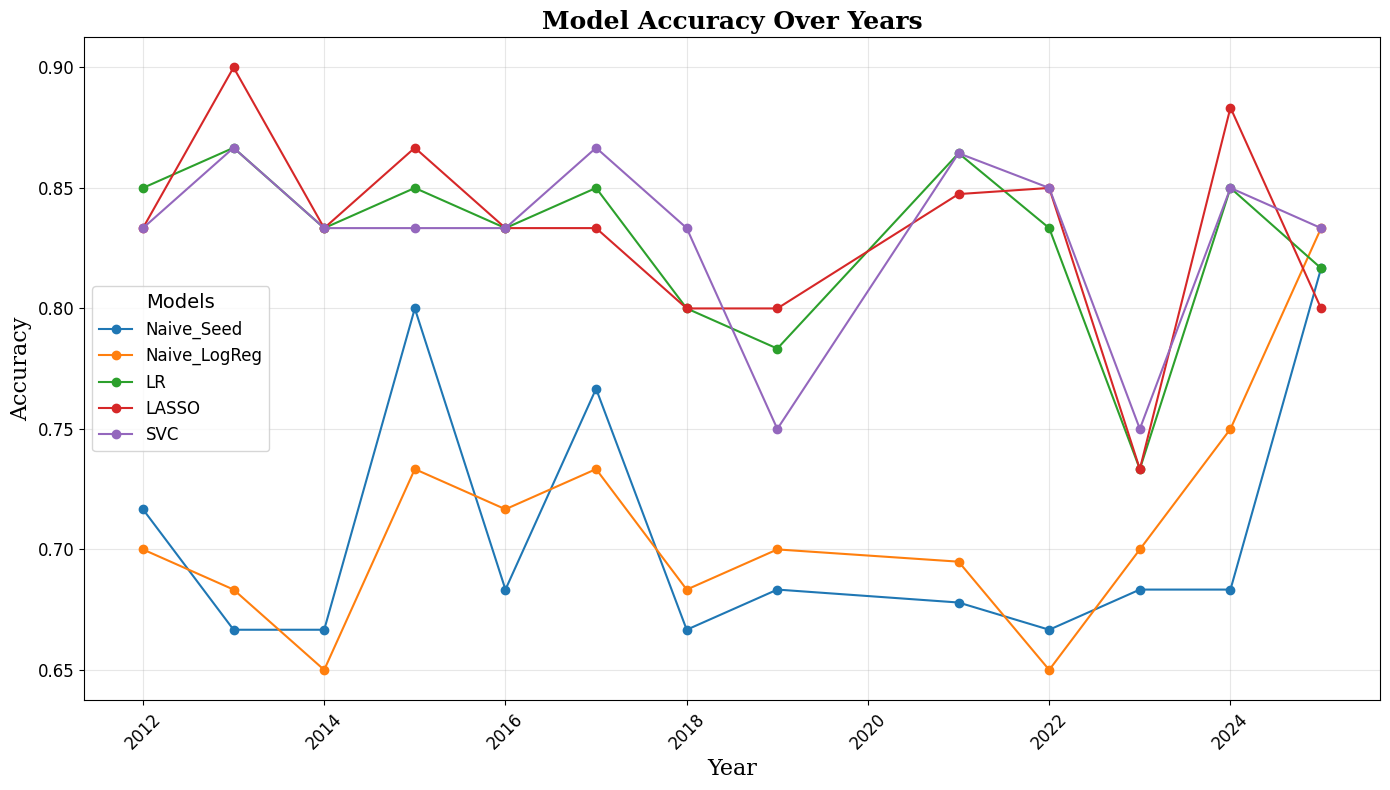

In [183]:
# Plot accuracy over years for each model
combined_df_final_model = combined_df.copy()

#df = pd.read_csv('Model Performances Train-Validation-Test.csv')

# If Year is the index, reset it to a column
if combined_df.index.name == 'Year' or 'Year' not in combined_df.columns:
    combined_df.reset_index(inplace=True)
    if 'index' in combined_df.columns and combined_df['index'].equals(combined_df['Year']):
        combined_df.drop('index', axis=1, inplace=True)

# Select Year and accuracy columns
selected_model_list = ['Naive_Seed', 'Naive_LogReg', 'LR', 'LASSO', 'SVC']
acc_cols = [col for col in combined_df.columns if col.endswith('_Acc') and any(model in col for model in selected_model_list)]
df_plot = combined_df[['Year'] + acc_cols]

# Set Year as index for plotting
df_plot.set_index('Year', inplace=True)

# Plot
plt.figure(figsize=(14, 8))
for col in acc_cols:
    plt.plot(df_plot.index, df_plot[col], marker='o', label=col.replace('_Acc', ''))

plt.title('Model Accuracy Over Years', fontsize=18, fontweight='bold', fontfamily='serif')
plt.xlabel('Year', fontsize=16, fontfamily='serif')
plt.ylabel('Accuracy', fontsize=16, fontfamily='serif')
plt.legend(title='Models', fontsize=12, title_fontsize=14, loc='best')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

In [62]:
acc_upset_cols = [col for col in final_performance_df.columns if col.endswith('_Acc')]
acc_upset_df = final_performance_df[acc_upset_cols]
acc_upset_df.describe()

,Naive_Seed_Acc,Naive_LogReg_Acc,LR_Acc,LASSO_Acc,SVC_Acc,KNN_Acc,RF_Acc
count,3.000000,3.000000,3.0000,3.000000,3.000000,3.000000,3.000000
mean,0.750000,0.791667,0.8250,0.850000,0.825000,0.783333,0.791667
std,0.066667,0.041667,0.0250,0.033333,0.008333,0.033333,0.025000
min,0.683333,0.750000,0.8000,0.816667,0.816667,0.750000,0.766667
25%,0.716667,0.770833,0.8125,0.833333,0.820833,0.766667,0.779167
50%,0.750000,0.791667,0.8250,0.850000,0.825000,0.783333,0.791667
75%,0.783333,0.812500,0.8375,0.866667,0.829167,0.800000,0.804167
max,0.816667,0.833333,0.8500,0.883333,0.833333,0.816667,0.816667


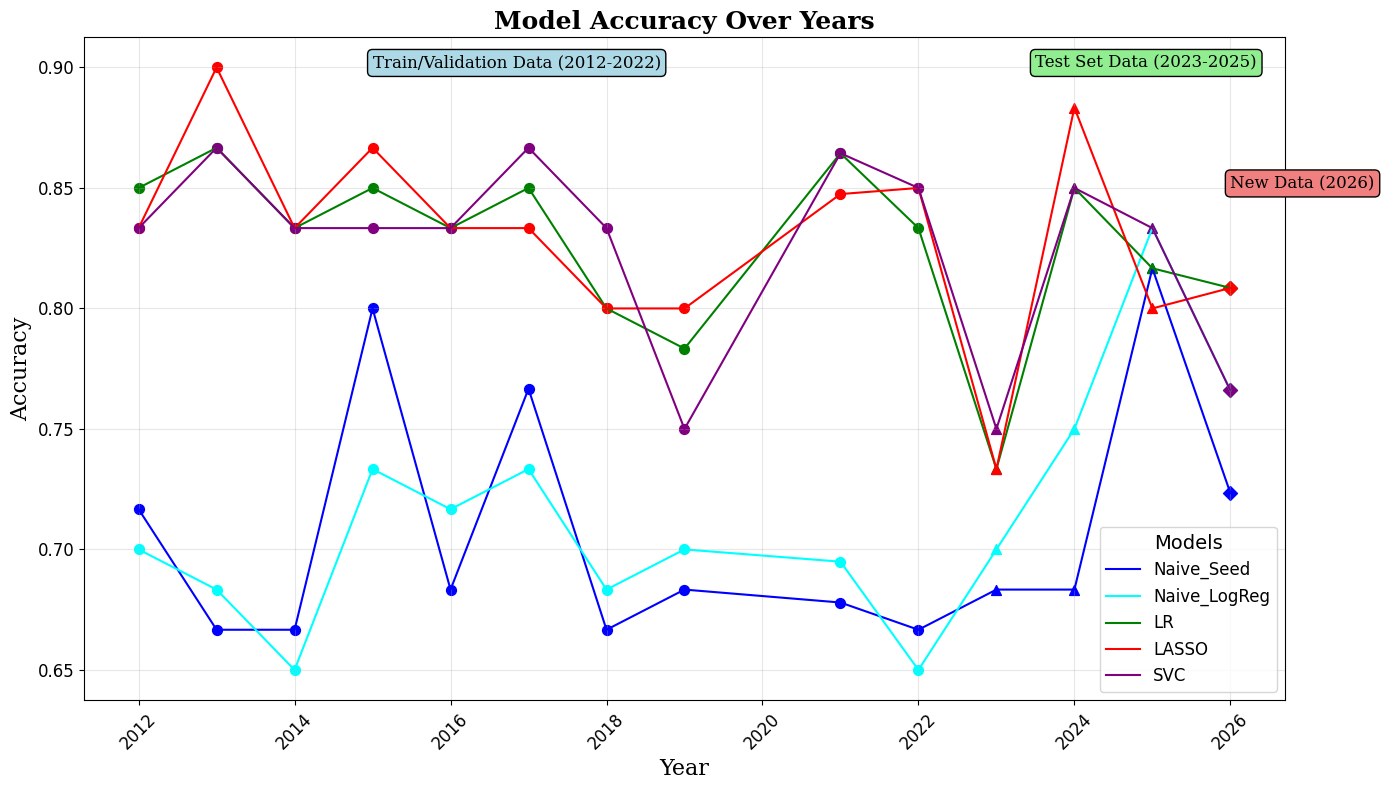

In [188]:
# New plot with 2026 data included
import matplotlib.pyplot as plt

df = pd.read_csv('Model Performances Train-Validation-Test.csv')

# If Year is the index, reset it to a column
if df.index.name == 'Year' or 'Year' not in df.columns:
    df.reset_index(inplace=True)
    if 'index' in df.columns and df['index'].equals(df['Year']):
        df.drop('index', axis=1, inplace=True)

# Select Year and accuracy columns for selected models
selected_models = ['Naive_Seed', 'Naive_LogReg', 'LR', 'LASSO', 'SVC']
acc_cols = [col for col in df.columns if col.endswith('_Acc') and any(col.startswith(model + '_') for model in selected_models)]
df_plot = df[['Year'] + acc_cols]

# Set Year as index for plotting
df_plot.set_index('Year', inplace=True)

# 2026 data
year_2026 = 2026
acc_2026 = {
    'Naive_Seed_Acc': 0.723404255319149,
    'Naive_LogReg_Acc': 0.7659574468085106,
    'LR_Acc': 0.8085106382978723,
    'LASSO_Acc': 0.8085106382978723,
    'SVC_Acc': 0.7659574468085106
}

# Define colors for each model
model_colors = {
    'Naive_Seed': 'blue',
    'Naive_LogReg': 'cyan',
    'LR': 'green',
    'LASSO': 'red',
    'SVC': 'purple'
}

# Plot
plt.figure(figsize=(14, 8))
for col in acc_cols:
    model_name = col.replace('_Acc', '')
    color = model_colors[model_name]
    
    # Collect all data points
    years = list(df_plot.index) + [year_2026]
    accs = list(df_plot[col]) + [acc_2026[col]]
    
    # Plot the continuous line
    plt.plot(years, accs, linestyle='-', color=color, label=model_name)
    
    # Overlay markers for different periods
    # Train/Val: 2012-2023, marker='o'
    train_years = [y for y in years if y < 2023]
    train_accs = [accs[i] for i, y in enumerate(years) if y < 2023]
    plt.scatter(train_years, train_accs, marker='o', color=color, s=50)
    
    # Test: 2024-2025, marker='^'
    test_years = [y for y in years if 2023 <= y <= 2025]
    test_accs = [accs[i] for i, y in enumerate(years) if 2023 <= y <= 2025]
    plt.scatter(test_years, test_accs, marker='^', color=color, s=50)
    
    # New: 2026, marker='D'
    plt.scatter([year_2026], [acc_2026[col]], marker='D', color=color, s=50)

plt.title('Model Accuracy Over Years', fontsize=18, fontweight='bold', fontfamily='serif')
plt.xlabel('Year', fontsize=16, fontfamily='serif')
plt.ylabel('Accuracy', fontsize=16, fontfamily='serif')
plt.legend(title='Models', fontsize=12, title_fontsize=14, loc='best')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)
# Add labels for data types
plt.text(2015, 0.9, 'Train/Validation Data (2012-2022)', fontsize=12, fontfamily='serif', bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue"))
plt.text(2023.5, 0.9, 'Test Set Data (2023-2025)', fontsize=12, fontfamily='serif', bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgreen"))
plt.text(2026, 0.85, 'New Data (2026)', fontsize=12, fontfamily='serif', bbox=dict(boxstyle="round,pad=0.3", facecolor="lightcoral"))
plt.tight_layout()
plt.show()

In [64]:
acc_upset_df

,Naive_Seed_Acc,Naive_LogReg_Acc,LR_Acc,LASSO_Acc,SVC_Acc,KNN_Acc,RF_Acc
Year,,,,,,,
2024,0.683333,0.750000,0.850,0.883333,0.833333,0.750000,0.766667
2025,0.816667,0.833333,0.800,0.816667,0.816667,0.816667,0.816667
Total,0.750000,0.791667,0.825,0.850000,0.825000,0.783333,0.791667


C:\Users\BQFAN\AppData\Local\Temp\ipykernel_46824\1113656039.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\BQFAN\AppData\Local\Temp\ipykernel_46824\1113656039.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


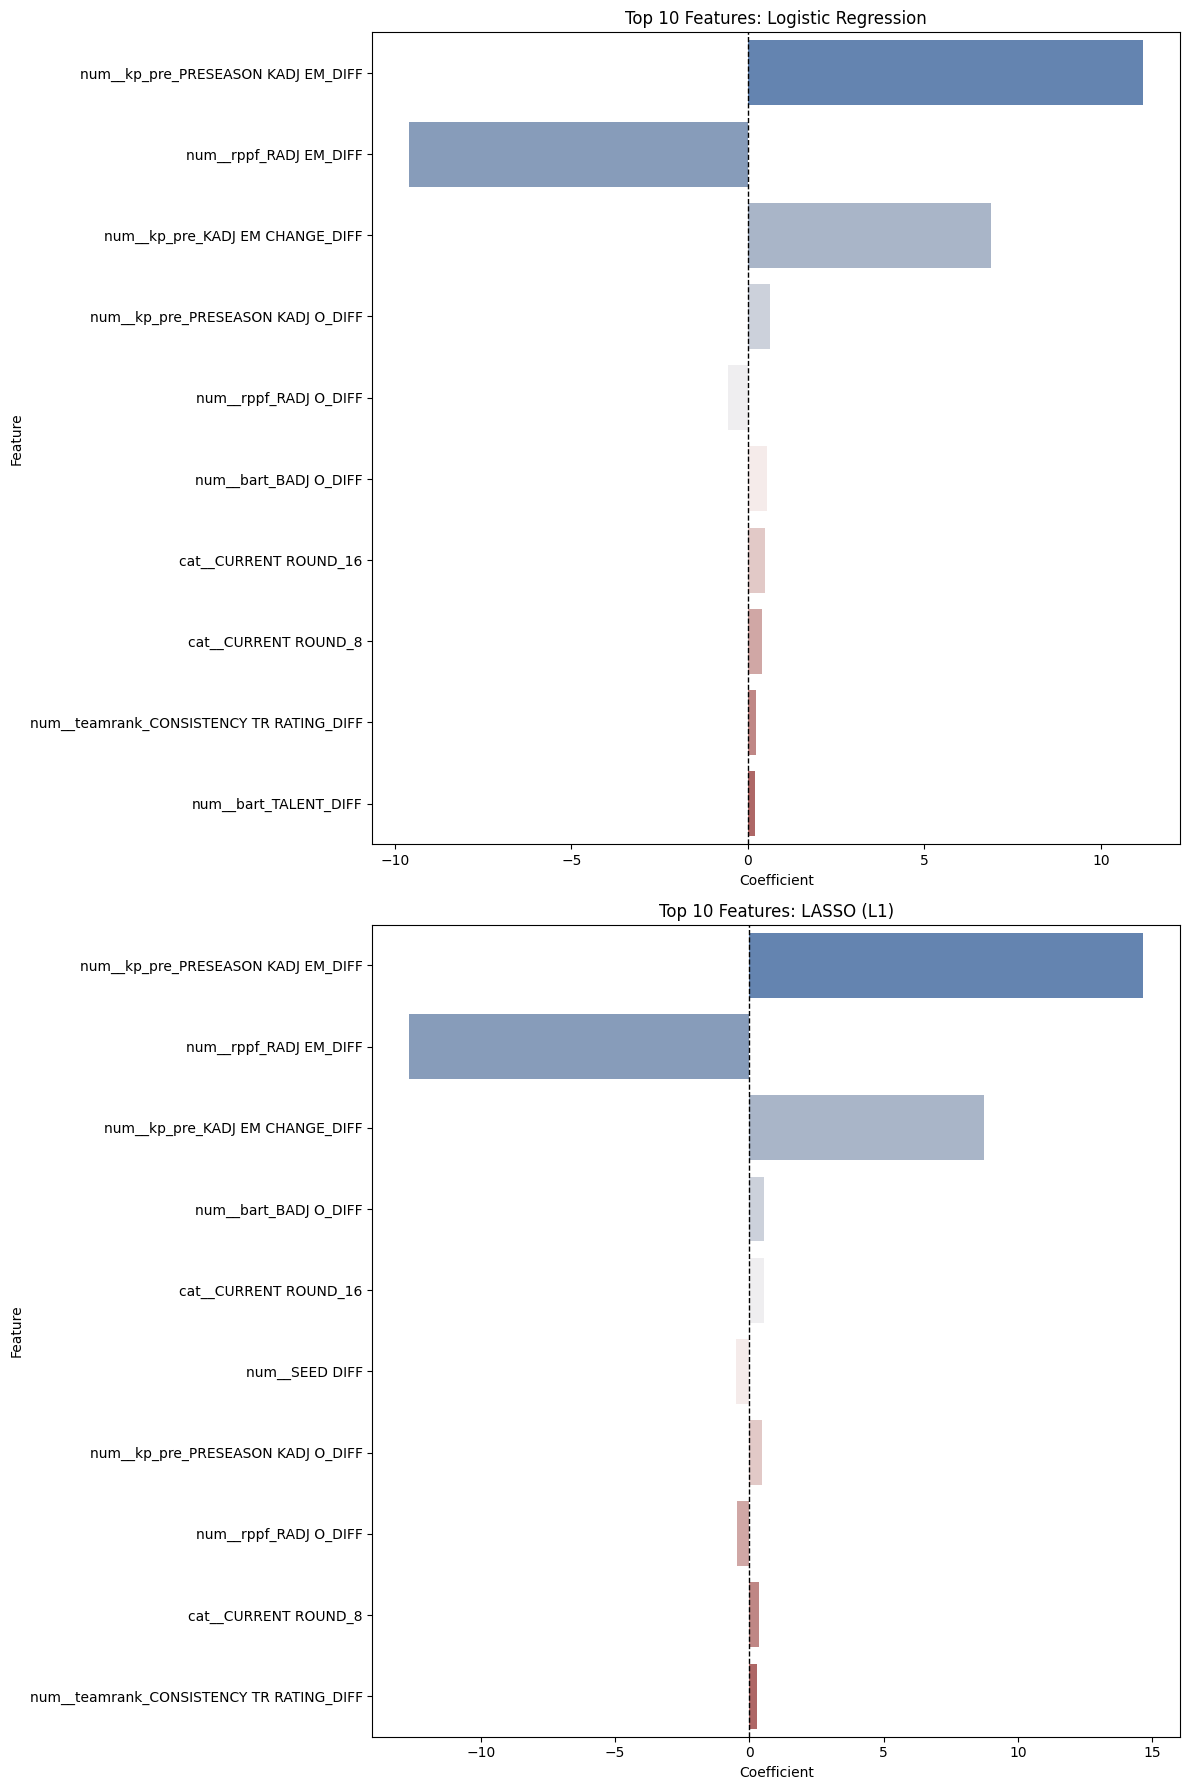

In [59]:
import matplotlib.pyplot as plt

def plot_feature_importance(pipe, model_name, ax, limit=10):
    """
    Extracts coefficients from a fitted pipeline and creates a bar plot.
    """
    # 1. Get feature names from the preprocessor
    feature_names = pipe.named_steps["preprocessor"].get_feature_names_out()
    
    # 2. Extract coefficients from the model
    # For binary classification, coef_ is a 2D array
    coefs = pipe.named_steps["model"].coef_[0]
    
    # 3. Create a DataFrame for sorting
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Coefficient': coefs,
        'Abs_Coef': np.abs(coefs)
    }).sort_values(by='Abs_Coef', ascending=False).head(limit)
    
    # 4. Create the plot
    sns.barplot(
        data=importance_df, 
        x='Coefficient', 
        y='Feature', 
        ax=ax, 
        palette='vlag'
    )
    ax.set_title(f'Top {limit} Features: {model_name}')
    ax.axvline(x=0, color='black', linestyle='--', linewidth=1)


models_to_plot = {
    'Logistic Regression': lr_model,
    'LASSO (L1)': lasso_model,
}

# Setup the plotting area
fig, axes = plt.subplots(2, 1, figsize=(12, 18))

for i, (name, model_obj) in enumerate(models_to_plot.items()):
    # Fit the pipeline on the full training set (Pre-2024)
    pipeline.set_params(model=model_obj)
    pipeline.fit(X_train_full, y_train_full)
    
    # Plot to the designated subplot
    plot_feature_importance(pipeline, name, axes[i])

plt.tight_layout()
plt.show()

### 2026 Data

In [68]:
data_2026 = pd.read_csv("2026_actual_cols.csv")
data_2026.describe()

,YEAR,TEAM NO 1,SEED 1,TEAM NO 2,SEED 2,CURRENT ROUND,kp_pre_PRESEASON KADJ EM_DIFF,rppf_RADJ EM_DIFF,kp_pre_KADJ EM CHANGE_DIFF,rppf_pre_RPPF RATING CHANGE RANK_DIFF,...,z_SEED LIST_DIFF,bart_TALENT_DIFF,ap_AP VOTES_DIFF,bart_BADJ O_DIFF,rppf_RADJ O_DIFF,shoot_FARTHER TWOS FG%_DIFF,teamrank_CONSISTENCY TR RATING_DIFF,SEED DIFF,bart_WAB_DIFF,TEAM 1 WIN
count,74.0,74.000000,74.000000,74.000000,74.000000,74.000000,74.000000,74.000000,74.000000,74.000000,...,74.000000,74.000000,53.000000,74.000000,74.000000,74.000000,74.000000,74.000000,74.000000,47.000000
mean,2026.0,1190.486486,3.189189,1175.864865,9.945946,45.837838,12.531216,15.367568,2.352432,-7.243243,...,-27.810811,28.185405,642.471698,7.337838,7.024324,1.162162,0.378378,-6.756757,5.409865,0.723404
std,0.0,19.763148,2.156073,18.753867,3.534146,18.410113,12.465335,12.070343,6.690814,85.874520,...,16.917751,28.146513,479.019656,8.556480,8.063138,4.850807,1.910768,4.009615,4.351829,0.452151
min,2026.0,1149.000000,1.000000,1148.000000,4.000000,16.000000,-11.100000,-3.100000,-20.760000,-185.000000,...,-64.000000,-34.623000,-357.000000,-9.300000,-8.800000,-9.200000,-4.600000,-15.000000,-2.500000,0.000000
25%,2026.0,1181.000000,1.000000,1160.250000,7.000000,32.000000,3.975000,6.875000,-2.237500,-82.250000,...,-35.750000,7.659000,110.000000,0.825000,1.350000,-2.000000,-0.500000,-8.000000,2.125000,0.000000
50%,2026.0,1195.000000,3.000000,1171.500000,10.000000,32.000000,12.015000,13.300000,2.490000,4.000000,...,-29.000000,30.063500,767.000000,7.400000,6.150000,1.350000,0.500000,-7.000000,4.600000,1.000000
75%,2026.0,1207.000000,4.000000,1189.750000,12.000000,64.000000,18.212500,19.675000,7.270000,51.250000,...,-14.000000,46.752000,994.000000,13.350000,11.200000,4.225000,1.750000,-3.000000,7.725000,1.000000
max,2026.0,1214.000000,8.000000,1215.000000,16.000000,64.000000,42.570000,46.600000,15.740000,234.000000,...,-3.000000,87.283000,1413.000000,26.700000,26.300000,13.600000,3.900000,-1.000000,15.300000,1.000000


In [69]:
data_2026.dropna(subset=['TEAM 1 WIN'], inplace=True)
df_for_modeling_2026 = data_2026.drop(columns = ['YEAR', 'TEAM NO 1', 'TEAM 1', 'TEAM NO 2', 'TEAM 2'])
df_for_modeling_2026.describe()

,SEED 1,SEED 2,CURRENT ROUND,kp_pre_PRESEASON KADJ EM_DIFF,rppf_RADJ EM_DIFF,kp_pre_KADJ EM CHANGE_DIFF,rppf_pre_RPPF RATING CHANGE RANK_DIFF,kp_pre_PRESEASON KADJ O_DIFF,z_SEED LIST_DIFF,bart_TALENT_DIFF,ap_AP VOTES_DIFF,bart_BADJ O_DIFF,rppf_RADJ O_DIFF,shoot_FARTHER TWOS FG%_DIFF,teamrank_CONSISTENCY TR RATING_DIFF,SEED DIFF,bart_WAB_DIFF,TEAM 1 WIN
count,47.000000,47.000000,47.000000,47.000000,47.000000,47.000000,47.000000,47.000000,47.000000,47.000000,29.000000,47.000000,47.000000,47.000000,47.000000,47.000000,47.000000,47.000000
mean,3.829787,10.978723,53.787234,14.269787,16.110638,1.275319,11.531915,7.906383,-29.702128,34.641766,496.655172,8.436170,8.310638,1.059574,0.382979,-7.148936,5.476596,0.723404
std,2.239169,3.172500,15.077966,13.568404,13.405454,6.985122,90.354820,7.705740,18.214799,29.188444,517.974094,9.092171,8.540880,4.426190,1.936528,4.328765,4.760409,0.452151
min,1.000000,5.000000,32.000000,-11.100000,-3.100000,-20.760000,-185.000000,-7.800000,-64.000000,-34.623000,-357.000000,-9.300000,-8.800000,-9.200000,-4.600000,-15.000000,-2.500000,0.000000
25%,2.000000,9.000000,32.000000,4.885000,4.750000,-3.420000,-54.000000,3.650000,-42.500000,16.488500,31.000000,1.800000,1.900000,-1.450000,-0.600000,-10.000000,1.900000,0.000000
50%,3.000000,11.000000,64.000000,14.050000,15.200000,1.290000,16.000000,9.000000,-31.000000,40.810000,378.000000,8.700000,7.500000,1.100000,0.400000,-7.000000,4.630000,1.000000
75%,5.500000,13.500000,64.000000,23.875000,24.500000,5.820000,73.000000,13.400000,-14.000000,51.359500,817.000000,14.450000,13.000000,3.900000,1.950000,-3.000000,8.450000,1.000000
max,8.000000,16.000000,64.000000,42.570000,46.600000,15.740000,234.000000,25.700000,-3.000000,87.283000,1401.000000,26.700000,26.300000,13.600000,3.900000,-1.000000,15.300000,1.000000


In [70]:
df_for_modeling_2026.drop(columns = ['rppf_pre_RPPF RATING CHANGE RANK_DIFF', 'z_SEED LIST_DIFF', 'ap_AP VOTES_DIFF'], inplace = True)
df_for_modeling_2026.info()

<class 'pandas.core.frame.DataFrame'>
Index: 47 entries, 0 to 64
Data columns (total 15 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   SEED 1                               47 non-null     int64  
 1   SEED 2                               47 non-null     int64  
 2   CURRENT ROUND                        47 non-null     int64  
 3   kp_pre_PRESEASON KADJ EM_DIFF        47 non-null     float64
 4   rppf_RADJ EM_DIFF                    47 non-null     float64
 5   kp_pre_KADJ EM CHANGE_DIFF           47 non-null     float64
 6   kp_pre_PRESEASON KADJ O_DIFF         47 non-null     float64
 7   bart_TALENT_DIFF                     47 non-null     float64
 8   bart_BADJ O_DIFF                     47 non-null     float64
 9   rppf_RADJ O_DIFF                     47 non-null     float64
 10  shoot_FARTHER TWOS FG%_DIFF          47 non-null     float64
 11  teamrank_CONSISTENCY TR RATING_DIFF  47

In [99]:
df_for_modeling_2026.columns

Index(['SEED 1', 'SEED 2', 'CURRENT ROUND', 'kp_pre_PRESEASON KADJ EM_DIFF',
       'rppf_RADJ EM_DIFF', 'kp_pre_KADJ EM CHANGE_DIFF',
       'kp_pre_PRESEASON KADJ O_DIFF', 'bart_TALENT_DIFF', 'bart_BADJ O_DIFF',
       'rppf_RADJ O_DIFF', 'shoot_FARTHER TWOS FG%_DIFF',
       'teamrank_CONSISTENCY TR RATING_DIFF', 'SEED DIFF', 'bart_WAB_DIFF',
       'TEAM 1 WIN'],
      dtype='object')

In [72]:
X_test_2026 = df_for_modeling_2026.drop(columns = ['TEAM 1 WIN'])
y_test_2026 = df_for_modeling_2026['TEAM 1 WIN']
### We will use the previously trained models to predict on the 2026 data
# Naive Seed Baseline
y_naive_pred_2026 = (data_2026['SEED 1'] < data_2026['SEED 2']).astype(int)
acc_naive_2026 = accuracy_score(y_test_2026, y_naive_pred_2026)
print("Naive Seed Baseline Performance on 2026: ", acc_naive_2026)

Naive Seed Baseline Performance on 2026:  0.723404255319149


In [73]:
###now ran the X_test_2026 through the pipelines for the other models (LR, LASSO, SVC, KNN, RF)
# We will use the same pipelines that were trained on the pre-2024 data
# Pipeline to convert the 2026 data in the same way as the training data
# Naive Logistic Regression
X_test_2026_naive = X_test_2026[naive_logreg_features]
X_test_2026_naive_scaled = sc_naive.transform(X_test_2026_naive)
y_naive_lr_pred_2026 = logistic_naive.predict(X_test_2026_naive_scaled)
acc_naive_lr_2026 = accuracy_score(y_test_2026, y_naive_lr_pred_2026)
print("Naive Logistic Regression Performance on 2026: ", acc_naive_lr_2026)

Naive Logistic Regression Performance on 2026:  0.7659574468085106


In [74]:
# Logistic Regression
y_lr_pred_2026 = model_pipelines['LR'].predict(X_test_2026)
acc_lr_2026 = accuracy_score(y_test_2026, y_lr_pred_2026)
print("Logistic Regression Performance on 2026: ", acc_lr_2026)

Logistic Regression Performance on 2026:  0.8085106382978723


In [76]:
# LASSO Regression
y_lasso_pred_2026 = model_pipelines['LASSO'].predict(X_test_2026)
acc_lasso_2026 = accuracy_score(y_test_2026, y_lasso_pred_2026)
print("LASSO Regression Performance on 2026: ", acc_lasso_2026)

LASSO Regression Performance on 2026:  0.8085106382978723


In [77]:
# SVC Model
y_svc_pred_2026 = model_pipelines['SVC'].predict(X_test_2026)
acc_svc_2026 = accuracy_score(y_test_2026, y_svc_pred_2026)
print("SVC Performance on 2026: ", acc_svc_2026)

SVC Performance on 2026:  0.7659574468085106


### Prediction 2026

In [109]:
prediction_dataframe = pd.read_csv("2026_actual_cols.csv")
prediction_dataframe.iloc[69]

YEAR                                           2026
TEAM NO 1                                      1206
TEAM 1                                      Florida
SEED 1                                            1
TEAM NO 2                                      1153
TEAM 2                                   Vanderbilt
SEED 2                                            5
CURRENT ROUND                                    16
kp_pre_PRESEASON KADJ EM_DIFF                  7.56
rppf_RADJ EM_DIFF                               6.7
kp_pre_KADJ EM CHANGE_DIFF                    -1.28
rppf_pre_RPPF RATING CHANGE RANK_DIFF            41
kp_pre_PRESEASON KADJ O_DIFF                    4.6
z_SEED LIST_DIFF                                -13
bart_TALENT_DIFF                              5.725
ap_AP VOTES_DIFF                              683.0
bart_BADJ O_DIFF                               -1.5
rppf_RADJ O_DIFF                               -0.8
shoot_FARTHER TWOS FG%_DIFF                     1.3
teamrank_CON

In [189]:
prediction_dataframe.columns

Index(['SEED 1', 'SEED 2', 'CURRENT ROUND', 'kp_pre_PRESEASON KADJ EM_DIFF',
       'rppf_RADJ EM_DIFF', 'kp_pre_KADJ EM CHANGE_DIFF',
       'rppf_pre_RPPF RATING CHANGE RANK_DIFF', 'kp_pre_PRESEASON KADJ O_DIFF',
       'z_SEED LIST_DIFF', 'bart_TALENT_DIFF', 'ap_AP VOTES_DIFF',
       'bart_BADJ O_DIFF', 'rppf_RADJ O_DIFF', 'shoot_FARTHER TWOS FG%_DIFF',
       'teamrank_CONSISTENCY TR RATING_DIFF', 'SEED DIFF', 'bart_WAB_DIFF'],
      dtype='object')

In [110]:
prediction_dataframe.iloc[[67,70,72]]

,YEAR,TEAM NO 1,TEAM 1,SEED 1,TEAM NO 2,TEAM 2,SEED 2,CURRENT ROUND,kp_pre_PRESEASON KADJ EM_DIFF,rppf_RADJ EM_DIFF,...,z_SEED LIST_DIFF,bart_TALENT_DIFF,ap_AP VOTES_DIFF,bart_BADJ O_DIFF,rppf_RADJ O_DIFF,shoot_FARTHER TWOS FG%_DIFF,teamrank_CONSISTENCY TR RATING_DIFF,SEED DIFF,bart_WAB_DIFF,TEAM 1 WIN
67,2026,1207,Duke,1,1165,St. John's,5,16,2.90,13.2,...,-17,21.077,558.0,4.1,7.9,3.5,0.4,-4,3.6,NaN
70,2026,1213,Arizona,1,1212,Arkansas,4,16,3.79,11.6,...,-14,-7.019,622.0,2.3,-0.5,9.0,-4.0,-3,6.6,NaN
72,2026,1184,Michigan,1,1214,Alabama,4,16,3.58,11.8,...,-11,-3.703,872.0,-1.6,-2.6,-4.5,2.7,-3,6.1,NaN


In [111]:
###Now we fit those data into the pipeline
prediction_dataframe = prediction_dataframe.iloc[[67,70,72]]
#prediction_dataframe.dropna(subset=['TEAM 1 WIN'], inplace=True)
prediction_dataframe = prediction_dataframe.drop(columns = ['YEAR', 'TEAM NO 1', 'TEAM 1', 'TEAM NO 2', 'TEAM 2', 'TEAM 1 WIN'])
prediction_dataframe

,SEED 1,SEED 2,CURRENT ROUND,kp_pre_PRESEASON KADJ EM_DIFF,rppf_RADJ EM_DIFF,kp_pre_KADJ EM CHANGE_DIFF,rppf_pre_RPPF RATING CHANGE RANK_DIFF,kp_pre_PRESEASON KADJ O_DIFF,z_SEED LIST_DIFF,bart_TALENT_DIFF,ap_AP VOTES_DIFF,bart_BADJ O_DIFF,rppf_RADJ O_DIFF,shoot_FARTHER TWOS FG%_DIFF,teamrank_CONSISTENCY TR RATING_DIFF,SEED DIFF,bart_WAB_DIFF
67,1,5,16,2.90,13.2,10.09,-108,4.1,-17,21.077,558.0,4.1,7.9,3.5,0.4,-4,3.6
70,1,4,16,3.79,11.6,7.82,-89,3.6,-14,-7.019,622.0,2.3,-0.5,9.0,-4.0,-3,6.6
72,1,4,16,3.58,11.8,8.30,-83,-0.5,-11,-3.703,872.0,-1.6,-2.6,-4.5,2.7,-3,6.1


In [112]:
y_lr_actual_pred = model_pipelines['LR'].predict(prediction_dataframe)
y_lr_actual_pred

array([1, 1, 1])

In [113]:
y_lasso_actual_pred = model_pipelines['LASSO'].predict(prediction_dataframe)
y_lasso_actual_pred

array([1, 1, 1])

In [114]:
y_svc_actual_pred = model_pipelines['SVC'].predict(prediction_dataframe)
y_svc_actual_pred

array([1, 1, 1])

### final predictions

In [190]:


# Load the 2026 team feature data
df_features = pd.read_csv('2026_matched_team_features.csv')

# Define the pairings for the Round of 16 (Round 16)
# Standardized to match the 'TEAM' column in the CSV
matchups = [
    ("Duke", "St. John's"),
    ("Michigan St.", "Connecticut"),
    ("Iowa", "Nebraska"),
    ("Illinois", "Houston"),
    ("Arizona", "Arkansas"),
    ("Texas", "Purdue"),
    ("Michigan", "Alabama"),
    ("Tennessee", "Iowa St.")
]

# Map teams to stats for quick lookup
stats_dict = df_features.set_index('TEAM').to_dict('index')

matchup_rows = []
for t1_name, t2_name in matchups:
    t1 = stats_dict[t1_name]
    t2 = stats_dict[t2_name]
    
    # Calculate difference-based features (Team 1 - Team 2)
    data = {
        'TEAM 1': t1_name,
        'TEAM 2': t2_name,
        'SEED 1': t1['SEED'],
        'SEED 2': t2['SEED'],
        'CURRENT ROUND': 16,
        'SEED DIFF': t1['SEED'] - t2['SEED'],
        
        # Calculate Diffs for existing metrics
        'kp_pre_PRESEASON KADJ EM_DIFF': t1['kp_pre_PRESEASON KADJ EM'] - t2['kp_pre_PRESEASON KADJ EM'],
        'rppf_RADJ EM_DIFF': t1['rppf_RADJ EM'] - t2['rppf_RADJ EM'],
        'kp_pre_KADJ EM CHANGE_DIFF': t1['kp_pre_KADJ EM CHANGE'] - t2['kp_pre_KADJ EM CHANGE'],
        'kp_pre_PRESEASON KADJ O_DIFF': t1['kp_pre_PRESEASON KADJ O'] - t2['kp_pre_PRESEASON KADJ O'],
        'bart_TALENT_DIFF': t1['bart_TALENT'] - t2['bart_TALENT'],
        'bart_BADJ O_DIFF': t1['bart_BADJ O'] - t2['bart_BADJ O'],
        'rppf_RADJ O_DIFF': t1['rppf_RADJ O'] - t2['rppf_RADJ O'],
        'shoot_FARTHER TWOS FG%_DIFF': t1['shoot_FARTHER TWOS FG%'] - t2['shoot_FARTHER TWOS FG%'],
        'teamrank_CONSISTENCY TR RATING_DIFF': t1['teamrank_CONSISTENCY TR RATING'] - t2['teamrank_CONSISTENCY TR RATING'],
        'bart_WAB_DIFF': t1['bart_WAB'] - t2['bart_WAB'],
        
        # Initialize features not found in source file to 0.0
        'rppf_pre_RPPF RATING CHANGE RANK_DIFF': 0.0,
        'z_SEED LIST_DIFF': 0.0,
        'ap_AP VOTES_DIFF': 0.0
    }
    matchup_rows.append(data)

# Create final dataframe and order columns by your model's feature list
feature_cols = [
    'SEED 1', 'SEED 2', 'CURRENT ROUND', 'kp_pre_PRESEASON KADJ EM_DIFF', 
    'rppf_RADJ EM_DIFF', 'kp_pre_KADJ EM CHANGE_DIFF', 
    'rppf_pre_RPPF RATING CHANGE RANK_DIFF', 'kp_pre_PRESEASON KADJ O_DIFF', 
    'z_SEED LIST_DIFF', 'bart_TALENT_DIFF', 'ap_AP VOTES_DIFF', 
    'bart_BADJ O_DIFF', 'rppf_RADJ O_DIFF', 'shoot_FARTHER TWOS FG%_DIFF', 
    'teamrank_CONSISTENCY TR RATING_DIFF', 'SEED DIFF', 'bart_WAB_DIFF'
]

df_round_16 = pd.DataFrame(matchup_rows)[['TEAM 1', 'TEAM 2'] + feature_cols]
df_round_16

,TEAM 1,TEAM 2,SEED 1,SEED 2,CURRENT ROUND,kp_pre_PRESEASON KADJ EM_DIFF,rppf_RADJ EM_DIFF,kp_pre_KADJ EM CHANGE_DIFF,rppf_pre_RPPF RATING CHANGE RANK_DIFF,kp_pre_PRESEASON KADJ O_DIFF,z_SEED LIST_DIFF,bart_TALENT_DIFF,ap_AP VOTES_DIFF,bart_BADJ O_DIFF,rppf_RADJ O_DIFF,shoot_FARTHER TWOS FG%_DIFF,teamrank_CONSISTENCY TR RATING_DIFF,SEED DIFF,bart_WAB_DIFF
0,Duke,St. John's,1,5,16,2.90,13.2,10.09,0.0,4.1,0.0,21.077,0.0,8.313,7.9,3.5,0.4,-4,6.40
1,Michigan St.,Connecticut,3,2,16,-7.67,0.9,8.11,0.0,-7.0,0.0,-15.472,0.0,-0.201,2.2,-3.5,-0.6,1,-1.40
2,Iowa,Nebraska,9,4,16,1.06,-3.7,-4.78,0.0,-0.1,0.0,-28.159,0.0,4.877,3.0,7.6,-0.2,5,-5.60
3,Illinois,Houston,3,2,16,-4.31,-1.2,2.98,0.0,1.0,0.0,-18.912,0.0,6.573,7.0,-1.5,1.6,1,-2.40
4,Arizona,Arkansas,1,4,16,3.79,11.6,7.82,0.0,3.6,0.0,-7.019,0.0,-1.011,-0.5,9.0,-4.0,-3,6.20
5,Texas,Purdue,11,2,16,-10.99,-12.9,-1.17,0.0,-10.8,0.0,-3.332,0.0,-9.231,-7.1,-2.9,-1.7,9,-9.41
6,Michigan,Alabama,1,4,16,3.58,11.8,8.30,0.0,-0.5,0.0,-3.703,0.0,-1.865,-2.6,-4.5,2.7,-3,7.50
7,Tennessee,Iowa St.,6,2,16,0.89,-6.8,-7.29,0.0,1.6,0.0,9.279,0.0,-2.270,-3.0,-1.5,-3.8,4,-3.30


In [192]:
df_round_16.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 19 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   TEAM 1                                 8 non-null      object 
 1   TEAM 2                                 8 non-null      object 
 2   SEED 1                                 8 non-null      int64  
 3   SEED 2                                 8 non-null      int64  
 4   CURRENT ROUND                          8 non-null      int64  
 5   kp_pre_PRESEASON KADJ EM_DIFF          8 non-null      float64
 6   rppf_RADJ EM_DIFF                      8 non-null      float64
 7   kp_pre_KADJ EM CHANGE_DIFF             8 non-null      float64
 8   rppf_pre_RPPF RATING CHANGE RANK_DIFF  8 non-null      float64
 9   kp_pre_PRESEASON KADJ O_DIFF           8 non-null      float64
 10  z_SEED LIST_DIFF                       8 non-null      float64
 11  bart_TALEN

In [193]:
prediction_dataframe_r16 = df_round_16.drop(columns = ['TEAM 1', 'TEAM 2'])
prediction_dataframe_r16

,SEED 1,SEED 2,CURRENT ROUND,kp_pre_PRESEASON KADJ EM_DIFF,rppf_RADJ EM_DIFF,kp_pre_KADJ EM CHANGE_DIFF,rppf_pre_RPPF RATING CHANGE RANK_DIFF,kp_pre_PRESEASON KADJ O_DIFF,z_SEED LIST_DIFF,bart_TALENT_DIFF,ap_AP VOTES_DIFF,bart_BADJ O_DIFF,rppf_RADJ O_DIFF,shoot_FARTHER TWOS FG%_DIFF,teamrank_CONSISTENCY TR RATING_DIFF,SEED DIFF,bart_WAB_DIFF
0,1,5,16,2.90,13.2,10.09,0.0,4.1,0.0,21.077,0.0,8.313,7.9,3.5,0.4,-4,6.40
1,3,2,16,-7.67,0.9,8.11,0.0,-7.0,0.0,-15.472,0.0,-0.201,2.2,-3.5,-0.6,1,-1.40
2,9,4,16,1.06,-3.7,-4.78,0.0,-0.1,0.0,-28.159,0.0,4.877,3.0,7.6,-0.2,5,-5.60
3,3,2,16,-4.31,-1.2,2.98,0.0,1.0,0.0,-18.912,0.0,6.573,7.0,-1.5,1.6,1,-2.40
4,1,4,16,3.79,11.6,7.82,0.0,3.6,0.0,-7.019,0.0,-1.011,-0.5,9.0,-4.0,-3,6.20
5,11,2,16,-10.99,-12.9,-1.17,0.0,-10.8,0.0,-3.332,0.0,-9.231,-7.1,-2.9,-1.7,9,-9.41
6,1,4,16,3.58,11.8,8.30,0.0,-0.5,0.0,-3.703,0.0,-1.865,-2.6,-4.5,2.7,-3,7.50
7,6,2,16,0.89,-6.8,-7.29,0.0,1.6,0.0,9.279,0.0,-2.270,-3.0,-1.5,-3.8,4,-3.30


In [195]:
y_lr_actual_pred = model_pipelines['LR'].predict(prediction_dataframe_r16)
y_lr_actual_pred

array([1, 0, 0, 1, 1, 0, 1, 0])

In [198]:
y_lasso_actual_pred = model_pipelines['LASSO'].predict(prediction_dataframe_r16)
y_lasso_actual_pred

array([1, 0, 0, 1, 1, 0, 1, 0])

In [199]:
y_svc_actual_pred = model_pipelines['SVC'].predict(prediction_dataframe_r16)
y_svc_actual_pred

array([1, 0, 0, 1, 1, 0, 1, 0])

In [196]:
df_features = pd.read_csv('2026_matched_team_features.csv')

# Pairing logic based on your quarterfinals prediction
matchups_8 = [
    ("Duke", "Connecticut"),
    ("Nebraska", "Illinois"),
    ("Arizona", "Purdue"),
    ("Michigan", "Iowa St.")
]

# Map teams to stats for lookup
stats_dict = df_features.set_index('TEAM').to_dict('index')

matchup_rows_8 = []
for t1_name, t2_name in matchups_8:
    t1 = stats_dict[t1_name]
    t2 = stats_dict[t2_name]
    
    data = {
        'TEAM 1': t1_name, 'TEAM 2': t2_name, 'SEED 1': t1['SEED'], 'SEED 2': t2['SEED'], 
        'CURRENT ROUND': 8, 'SEED DIFF': t1['SEED'] - t2['SEED'],
        
        # Calculating differentials
        'kp_pre_PRESEASON KADJ EM_DIFF': t1['kp_pre_PRESEASON KADJ EM'] - t2['kp_pre_PRESEASON KADJ EM'],
        'rppf_RADJ EM_DIFF': t1['rppf_RADJ EM'] - t2['rppf_RADJ EM'],
        'kp_pre_KADJ EM CHANGE_DIFF': t1['kp_pre_KADJ EM CHANGE'] - t2['kp_pre_KADJ EM CHANGE'],
        'kp_pre_PRESEASON KADJ O_DIFF': t1['kp_pre_PRESEASON KADJ O'] - t2['kp_pre_PRESEASON KADJ O'],
        'bart_TALENT_DIFF': t1['bart_TALENT'] - t2['bart_TALENT'],
        'bart_BADJ O_DIFF': t1['bart_BADJ O'] - t2['bart_BADJ O'],
        'rppf_RADJ O_DIFF': t1['rppf_RADJ O'] - t2['rppf_RADJ O'],
        'shoot_FARTHER TWOS FG%_DIFF': t1['shoot_FARTHER TWOS FG%'] - t2['shoot_FARTHER TWOS FG%'],
        'teamrank_CONSISTENCY TR RATING_DIFF': t1['teamrank_CONSISTENCY TR RATING'] - t2['teamrank_CONSISTENCY TR RATING'],
        'bart_WAB_DIFF': t1['bart_WAB'] - t2['bart_WAB'],
        
        # Missing features initialized to 0.0
        'rppf_pre_RPPF RATING CHANGE RANK_DIFF': 0.0, 'z_SEED LIST_DIFF': 0.0, 'ap_AP VOTES_DIFF': 0.0
    }
    matchup_rows_8.append(data)

# Ordering columns to match your model's feature list
feature_cols = ['SEED 1', 'SEED 2', 'CURRENT ROUND', 'kp_pre_PRESEASON KADJ EM_DIFF', 'rppf_RADJ EM_DIFF', 
                'kp_pre_KADJ EM CHANGE_DIFF', 'rppf_pre_RPPF RATING CHANGE RANK_DIFF', 
                'kp_pre_PRESEASON KADJ O_DIFF', 'z_SEED LIST_DIFF', 'bart_TALENT_DIFF', 
                'ap_AP VOTES_DIFF', 'bart_BADJ O_DIFF', 'rppf_RADJ O_DIFF', 
                'shoot_FARTHER TWOS FG%_DIFF', 'teamrank_CONSISTENCY TR RATING_DIFF', 
                'SEED DIFF', 'bart_WAB_DIFF']

df_round_8 = pd.DataFrame(matchup_rows_8)[['TEAM 1', 'TEAM 2'] + feature_cols]
df_round_8

,TEAM 1,TEAM 2,SEED 1,SEED 2,CURRENT ROUND,kp_pre_PRESEASON KADJ EM_DIFF,rppf_RADJ EM_DIFF,kp_pre_KADJ EM CHANGE_DIFF,rppf_pre_RPPF RATING CHANGE RANK_DIFF,kp_pre_PRESEASON KADJ O_DIFF,z_SEED LIST_DIFF,bart_TALENT_DIFF,ap_AP VOTES_DIFF,bart_BADJ O_DIFF,rppf_RADJ O_DIFF,shoot_FARTHER TWOS FG%_DIFF,teamrank_CONSISTENCY TR RATING_DIFF,SEED DIFF,bart_WAB_DIFF
0,Duke,Connecticut,1,2,8,-2.00,11.8,13.03,0.0,-0.8,0.0,6.895,0.0,5.058,6.5,-2.7,-0.3,-1,4.9
1,Nebraska,Illinois,4,3,8,-11.61,-6.6,5.67,0.0,-6.3,0.0,-20.598,0.0,-14.695,-13.3,-3.9,-0.6,1,0.9
2,Arizona,Purdue,1,2,8,-5.28,6.4,11.74,0.0,-5.9,0.0,14.206,0.0,-6.355,-3.4,-1.5,-4.2,-1,4.5
3,Michigan,Iowa St.,1,2,8,0.48,5.0,4.70,0.0,2.9,0.0,19.383,0.0,3.857,3.4,1.8,0.2,-1,6.6


In [197]:
prediction_dataframe_r8 = df_round_8.drop(columns = ['TEAM 1', 'TEAM 2'])
prediction_dataframe_r8

,SEED 1,SEED 2,CURRENT ROUND,kp_pre_PRESEASON KADJ EM_DIFF,rppf_RADJ EM_DIFF,kp_pre_KADJ EM CHANGE_DIFF,rppf_pre_RPPF RATING CHANGE RANK_DIFF,kp_pre_PRESEASON KADJ O_DIFF,z_SEED LIST_DIFF,bart_TALENT_DIFF,ap_AP VOTES_DIFF,bart_BADJ O_DIFF,rppf_RADJ O_DIFF,shoot_FARTHER TWOS FG%_DIFF,teamrank_CONSISTENCY TR RATING_DIFF,SEED DIFF,bart_WAB_DIFF
0,1,2,8,-2.00,11.8,13.03,0.0,-0.8,0.0,6.895,0.0,5.058,6.5,-2.7,-0.3,-1,4.9
1,4,3,8,-11.61,-6.6,5.67,0.0,-6.3,0.0,-20.598,0.0,-14.695,-13.3,-3.9,-0.6,1,0.9
2,1,2,8,-5.28,6.4,11.74,0.0,-5.9,0.0,14.206,0.0,-6.355,-3.4,-1.5,-4.2,-1,4.5
3,1,2,8,0.48,5.0,4.70,0.0,2.9,0.0,19.383,0.0,3.857,3.4,1.8,0.2,-1,6.6


In [200]:
y_lr_actual_pred_r8 = model_pipelines['LR'].predict(prediction_dataframe_r8)
y_lr_actual_pred_r8

array([1, 0, 1, 1])

In [201]:
y_lasso_actual_pred_r8 = model_pipelines['LASSO'].predict(prediction_dataframe_r8)
y_lasso_actual_pred_r8

array([1, 0, 1, 1])

In [202]:
y_svc_actual_pred_r8 = model_pipelines['SVC'].predict(prediction_dataframe_r8)
y_svc_actual_pred_r8

array([1, 0, 1, 1])

In [203]:
df_features = pd.read_csv('2026_matched_team_features.csv')

# Pairing logic based on your semi-final predictions
matchups_4 = [
    ("Duke", "Illinois"),
    ("Arizona", "Michigan")
]

# Map teams to stats for lookup
stats_dict = df_features.set_index('TEAM').to_dict('index')

matchup_rows_4 = []
for t1_name, t2_name in matchups_4:
    t1 = stats_dict[t1_name]
    t2 = stats_dict[t2_name]
    
    data = {
        'TEAM 1': t1_name, 'TEAM 2': t2_name, 'SEED 1': t1['SEED'], 'SEED 2': t2['SEED'], 
        'CURRENT ROUND': 4, 'SEED DIFF': t1['SEED'] - t2['SEED'],
        
        # Calculating differentials (T1 - T2)
        'kp_pre_PRESEASON KADJ EM_DIFF': t1['kp_pre_PRESEASON KADJ EM'] - t2['kp_pre_PRESEASON KADJ EM'],
        'rppf_RADJ EM_DIFF': t1['rppf_RADJ EM'] - t2['rppf_RADJ EM'],
        'kp_pre_KADJ EM CHANGE_DIFF': t1['kp_pre_KADJ EM CHANGE'] - t2['kp_pre_KADJ EM CHANGE'],
        'kp_pre_PRESEASON KADJ O_DIFF': t1['kp_pre_PRESEASON KADJ O'] - t2['kp_pre_PRESEASON KADJ O'],
        'bart_TALENT_DIFF': t1['bart_TALENT'] - t2['bart_TALENT'],
        'bart_BADJ O_DIFF': t1['bart_BADJ O'] - t2['bart_BADJ O'],
        'rppf_RADJ O_DIFF': t1['rppf_RADJ O'] - t2['rppf_RADJ O'],
        'shoot_FARTHER TWOS FG%_DIFF': t1['shoot_FARTHER TWOS FG%'] - t2['shoot_FARTHER TWOS FG%'],
        'teamrank_CONSISTENCY TR RATING_DIFF': t1['teamrank_CONSISTENCY TR RATING'] - t2['teamrank_CONSISTENCY TR RATING'],
        'bart_WAB_DIFF': t1['bart_WAB'] - t2['bart_WAB'],
        
        # Missing features initialized to 0.0
        'rppf_pre_RPPF RATING CHANGE RANK_DIFF': 0.0, 'z_SEED LIST_DIFF': 0.0, 'ap_AP VOTES_DIFF': 0.0
    }
    matchup_rows_4.append(data)

# Ordering columns to match your model's feature list
feature_cols = ['SEED 1', 'SEED 2', 'CURRENT ROUND', 'kp_pre_PRESEASON KADJ EM_DIFF', 'rppf_RADJ EM_DIFF', 
                'kp_pre_KADJ EM CHANGE_DIFF', 'rppf_pre_RPPF RATING CHANGE RANK_DIFF', 
                'kp_pre_PRESEASON KADJ O_DIFF', 'z_SEED LIST_DIFF', 'bart_TALENT_DIFF', 
                'ap_AP VOTES_DIFF', 'bart_BADJ O_DIFF', 'rppf_RADJ O_DIFF', 
                'shoot_FARTHER TWOS FG%_DIFF', 'teamrank_CONSISTENCY TR RATING_DIFF', 
                'SEED DIFF', 'bart_WAB_DIFF']

df_semi_finals = pd.DataFrame(matchup_rows_4)[['TEAM 1', 'TEAM 2'] + feature_cols]
df_semi_finals

,TEAM 1,TEAM 2,SEED 1,SEED 2,CURRENT ROUND,kp_pre_PRESEASON KADJ EM_DIFF,rppf_RADJ EM_DIFF,kp_pre_KADJ EM CHANGE_DIFF,rppf_pre_RPPF RATING CHANGE RANK_DIFF,kp_pre_PRESEASON KADJ O_DIFF,z_SEED LIST_DIFF,bart_TALENT_DIFF,ap_AP VOTES_DIFF,bart_BADJ O_DIFF,rppf_RADJ O_DIFF,shoot_FARTHER TWOS FG%_DIFF,teamrank_CONSISTENCY TR RATING_DIFF,SEED DIFF,bart_WAB_DIFF
0,Duke,Illinois,1,3,4,-0.44,6.9,7.24,0.0,0.0,0.0,28.105,0.0,-3.800,-3.5,1.6,-0.1,-2,7.1
1,Arizona,Michigan,1,1,4,-0.76,0.3,0.82,0.0,2.0,0.0,3.654,0.0,-0.701,1.2,3.4,-4.3,0,-0.3


In [204]:
prediction_dataframe_r4 = df_semi_finals.drop(columns = ['TEAM 1', 'TEAM 2'])
prediction_dataframe_r4

,SEED 1,SEED 2,CURRENT ROUND,kp_pre_PRESEASON KADJ EM_DIFF,rppf_RADJ EM_DIFF,kp_pre_KADJ EM CHANGE_DIFF,rppf_pre_RPPF RATING CHANGE RANK_DIFF,kp_pre_PRESEASON KADJ O_DIFF,z_SEED LIST_DIFF,bart_TALENT_DIFF,ap_AP VOTES_DIFF,bart_BADJ O_DIFF,rppf_RADJ O_DIFF,shoot_FARTHER TWOS FG%_DIFF,teamrank_CONSISTENCY TR RATING_DIFF,SEED DIFF,bart_WAB_DIFF
0,1,3,4,-0.44,6.9,7.24,0.0,0.0,0.0,28.105,0.0,-3.800,-3.5,1.6,-0.1,-2,7.1
1,1,1,4,-0.76,0.3,0.82,0.0,2.0,0.0,3.654,0.0,-0.701,1.2,3.4,-4.3,0,-0.3


In [205]:
y_lr_actual_pred_r4 = model_pipelines['LR'].predict(prediction_dataframe_r4)
y_lr_actual_pred_r4

array([1, 0])

In [206]:
y_lasso_actual_pred_r4 = model_pipelines['LASSO'].predict(prediction_dataframe_r4)
y_lasso_actual_pred_r4

array([1, 0])

In [207]:
y_svc_actual_pred_r4 = model_pipelines['SVC'].predict(prediction_dataframe_r4)
y_svc_actual_pred_r4

array([1, 0])

In [208]:
df_finals = pd.read_csv('final_matchup_2026.csv')
df_finals

,TEAM 1,TEAM 2,SEED 1,SEED 2,CURRENT ROUND,kp_pre_PRESEASON KADJ EM_DIFF,rppf_RADJ EM_DIFF,kp_pre_KADJ EM CHANGE_DIFF,rppf_pre_RPPF RATING CHANGE RANK_DIFF,kp_pre_PRESEASON KADJ O_DIFF,z_SEED LIST_DIFF,bart_TALENT_DIFF,ap_AP VOTES_DIFF,bart_BADJ O_DIFF,rppf_RADJ O_DIFF,shoot_FARTHER TWOS FG%_DIFF,teamrank_CONSISTENCY TR RATING_DIFF,SEED DIFF,bart_WAB_DIFF
0,Duke,Michigan,1,1,2,1.75,1.6,-0.45,0.0,3.9,0.0,21.309,0.0,0.515,0.9,0.1,-1.2,0,-0.3


In [210]:
prediction_dataframe_r2 = df_finals.drop(columns = ['TEAM 1', 'TEAM 2'])
prediction_dataframe_r2

,SEED 1,SEED 2,CURRENT ROUND,kp_pre_PRESEASON KADJ EM_DIFF,rppf_RADJ EM_DIFF,kp_pre_KADJ EM CHANGE_DIFF,rppf_pre_RPPF RATING CHANGE RANK_DIFF,kp_pre_PRESEASON KADJ O_DIFF,z_SEED LIST_DIFF,bart_TALENT_DIFF,ap_AP VOTES_DIFF,bart_BADJ O_DIFF,rppf_RADJ O_DIFF,shoot_FARTHER TWOS FG%_DIFF,teamrank_CONSISTENCY TR RATING_DIFF,SEED DIFF,bart_WAB_DIFF
0,1,1,2,1.75,1.6,-0.45,0.0,3.9,0.0,21.309,0.0,0.515,0.9,0.1,-1.2,0,-0.3


In [211]:
y_lr_actual_pred_r2 = model_pipelines['LR'].predict(prediction_dataframe_r2)
y_lr_actual_pred_r2

array([1])

In [213]:
y_lasso_actual_pred_r2 = model_pipelines['LASSO'].predict(prediction_dataframe_r2)
y_lasso_actual_pred_r2

array([1])

In [214]:
y_SVC_actual_pred_r2 = model_pipelines['SVC'].predict(prediction_dataframe_r2)
y_SVC_actual_pred_r2

array([1])